# 💻 **Evidencia 2**

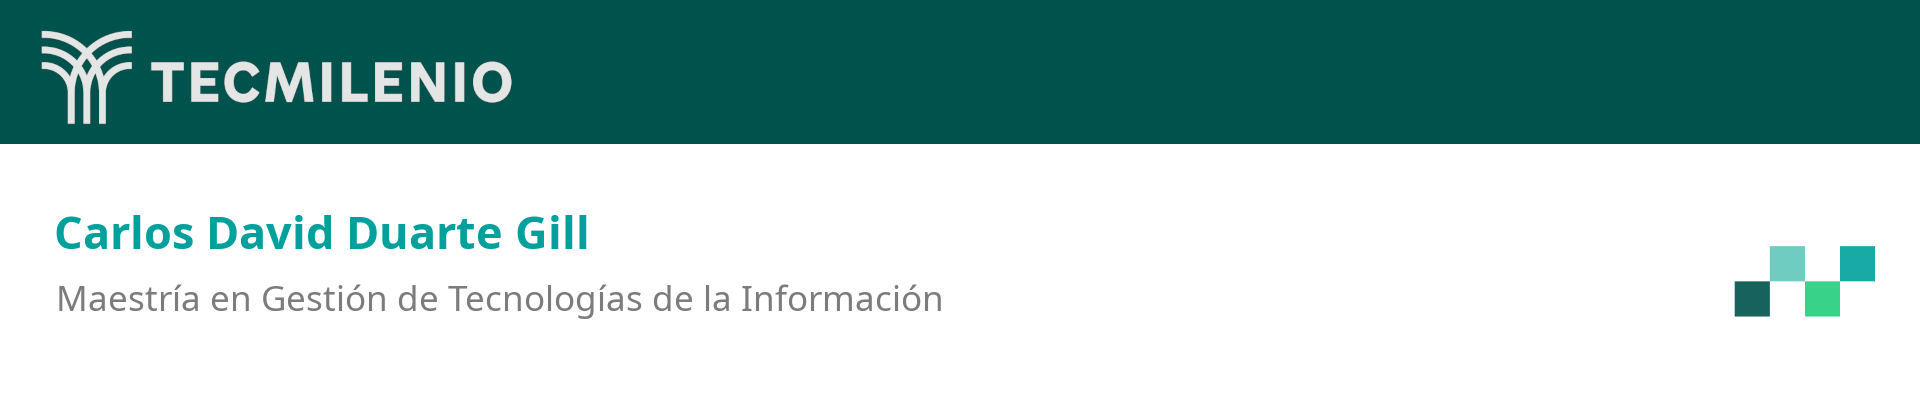

## **Aprendizaje automático y modelado predictivo**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Fabiola Cristina Olguín Barrón
- Fecha:  lunes 3 de noviembre de 2025

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 🔤 Introducción

En esta evidencia nos centraremos en aplicar técnicas de aprendizaje automático supervisado para comprender y predecir el valor medio de la vivienda en California, utilizando el conjunto de datos del Censo de 1990 en California disponible en la libería sklearn.datasets. El análisis explora las variables económicas, demográficas y geográficas que influyen en el precio de las propiedades en el estado de California.

## 🏠 Selección del conjunto de datos

Se seleccionó el conjunto de datos de Vivienda en California debido a su facilidad de incorporación, pues viene incluido en la librería de sklearn, además de ser un conjunto de datos reales basados el senso de vivienda en California del año 1990.

## 🗽 Alcance del análisis

El alcance de esta Evidencia 1 es la construcción, entrenamiento y evaluación de un modelo de regresión que utilice las diferentes variables predictoras disponibles para estimar el valor medio de una casa. El proceso incluirá la preparación de datos, la justificación de las decisiones técnicas y la validación del modelo mediante métricas de rendimiento y visualizaciones.

## ❓ Formulación de la pregunta de anális

Nuestro análisis para el conjunto de datos de viviendas estará sustentado en un problema de regresión para la predicción de un valor numérico, que en este caso, el objetivo será predecir el valor promedio de una casa habitación.

**En base a esto, se formula la siguiente pregunta de análisis clave:**
- 🧑 ¿Cómo influyen las variables socioeconómicas y geográficas de un grupo de manzanas en California para predecir el valor medio de la vivienda con la mayor precisión posible?

## 🏠 Contexto del caso

**¿De dónde vienen los datos?**

Los datos provienen del repositorio sklearn.datasets y contienen información detallada sobre grupos de manzanas del Censo de California de 1990.

**¿Qué se espera resolver?**

Se espera medir la relación entre las variables demográficas, económicas y geográficas con el precio promedio de la vivienda. El objetivo es construir un modelo que pueda predecir el valor promedio de una casa en cualquier grupo de manzanas de California, basándonos en estas características.

**¿Cuál es su utilidad?**

La utilidad de este modelo de predicción se encuentra principalmente en el rubro de bienes raíces, pues la utilidad de poder predecir futuros precios de casas habitación en la zona podría ayudar, por ejemplo, a una inmobiliaria a establecer precios de referencia por zonas. Las predicciones de precios también podrían ser aprovechadas por compañías de seguros para calcular el riesgo de los inmuebles y precios futuros. A su vez, estas predicciones podrían ser de gran provecho para la administración política de la región para estudiar el impacto de los salarios y edades de los trabajadores contra el valor de la vivienda en diferentes zonas geográficas.

# 🧰 Carga de todas las librerías necesarias

 A continuación se importan las librerías necesarias para el análisis y la visualización como numpy, scipy.stats, matplotlib.pyplot y seaborn, entre otras.

## 📚 Librerías

In [3]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# scales
from sklearn.preprocessing import MinMaxScaler
# labels categoricos
from sklearn.preprocessing import LabelEncoder
# segments
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# regresion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# multinomial
from sklearn.metrics import classification_report, confusion_matrix
# statsmodels
import statsmodels.api as sm
# charts roc
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestRegressor

# warnings
import warnings
warnings.filterwarnings('ignore')

print("-" * 80)
print("Librerias importadas!")
print("-" * 80)

--------------------------------------------------------------------------------
Librerias importadas!
--------------------------------------------------------------------------------


**🔍 Revisar sección, Información de librerias utilizadas, para mayor detalle**

## 🗂 Variables de entorno

In [4]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# estilo de las graficas
sns.set_style("white")
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_tecmi_dark="#00534c"
_color_teal="#20c997"
# colores generales
_color_purple="#6f42c1"
_color_pink="#e83e8c"
_color_orange="#fd7e14"
# colores boostrap
_color_primary="#007bff"
_color_gray="#6c757d"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"
# tamaños de fuente
_fontsize_title = 16
_fontsize_label = 12
_fontsize_marker = 9
# paletas de colores prearmadas
_paleta_tecmi = [_color_tecmi_light, _color_purple, _color_warning, _color_info, _color_primary]
_paleta_secundaria = [_color_tecmi_light, _color_primary, _color_purple]

print("-" * 80)
print("Variables de entorno cargadas!")
print("-" * 80)

--------------------------------------------------------------------------------
Variables de entorno cargadas!
--------------------------------------------------------------------------------


# 💾 Preparación de los datos

Para iniciar el análisis, cargaremos el conjunto de datos de Vivienda en California directamente desde la librería **sklearn.datasets**.

## 🗂 Carga del dataset

In [5]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# libreria con el dataset
from sklearn.datasets import fetch_california_housing

# conjunto de datos
housing = fetch_california_housing(as_frame=True)

# DataFrame
df_housing = housing.frame

# columna objetivo: valor promedio de una casa
# se verifica la creacion de la variable objetivo desde el frame
if 'MedHouseVal' not in df_housing.columns:
    df_housing['MedHouseVal'] = housing.target

## 🗂 Descripción del dataset

In [6]:
print("\n" + "="*80)
print("\033[1m --- Descripción del dataset --- \033[0m")
print("="*80)
print(housing.DESCR)


 --- Descripción del dataset --- 
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 199

## 🗂 Descripción del dataframe

In [7]:
print("\n" + "="*80)
print("\033[1m --- Estructura inicial del DataFrame --- \033[0m")
print("="*80)
df_housing.head()


 --- Estructura inicial del DataFrame --- 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [9]:
# nombres de columnas
_MedInc_ = 'MedInc'
_HouseAge_ = 'HouseAge'
_AveRooms_ = 'AveRooms'
_AveBedrms_ = 'AveBedrms'
_Population_ = 'Population'
_AveOccup_ = 'AveOccup'
_Latitude_ = 'Latitude'
_Longitude_ = 'Longitude'
# target
_MedHouseVal_ = 'MedHouseVal'

## 🔍 Información de la estructura

In [10]:
print("-" * 80)
print("\033[1m --- Dataset cargado correctamente --- \033[0m")
print("-"*80)
print(f"Dataset shape: {df_housing.shape}")
print(f"Número de filas: {df_housing.shape[0]}")
print(f"Número de columnas: {df_housing.shape[1]}")

--------------------------------------------------------------------------------
 --- Dataset cargado correctamente --- 
--------------------------------------------------------------------------------
Dataset shape: (20640, 9)
Número de filas: 20640
Número de columnas: 9


# 🩺 Diagnóstico y limpieza de registros mediante ETL

Se realiza un proceso sistemático de ETL para nuestro dataset, con el objetivo de limpieza y transformación de los datos.

## 🔍 Exploración inicial

In [11]:
# ------------------------------------------------------------------------------
# --- Diagnóstico Inicial ---
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("\033[1m --- Información del DataFrame --- \033[0m")
print("="*80)
df_housing.info()


 --- Información del DataFrame --- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [12]:
print("\n")
print("-" * 80)
print("\033[1m --- Estadísticas Descriptivas del Dataset --- \033[0m")
print("-"*80)

df_housing.describe()



--------------------------------------------------------------------------------
 --- Estadísticas Descriptivas del Dataset --- 
--------------------------------------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


El dataset no continene nulos, tampoco contiene valores negativos en las columnas númericas. Se continua con el diagnóstico.

## 🔴 Detección y eliminación de duplicados

Se revisa si nuestro dataset **Vivienda en California** cuenta con registros duplicados, para ser eliminados y evitar que sesguen el análisis.

In [13]:
print("=" * 80)
print("\033[1m --- Limpieza de registros duplicados: --- \033[0m")
print("=" * 80)
print(f"Número de filas antes de la limpieza: {df_housing.shape[0]}")
# contamos los registros duplicados
total_duplicados = df_housing.duplicated().sum()
print(f"Registros \033[1m duplicados encontrados: {total_duplicados}\033[0m")
# eliminamos duplicados y nos aseguramos de que df_limpio sea una copia explícita
df_limpio = df_housing.drop_duplicates().copy()
# resultados
print("-" * 80)
print(f"\nNúmero de \033[1m filas después de la limpieza: {df_limpio.shape[0]}\033[0m")
print(f"Número de columnas después de la limpieza: \033[1m {df_limpio.shape[1]}\033[0m")

 --- Limpieza de registros duplicados: --- 
Número de filas antes de la limpieza: 20640
Registros  duplicados encontrados: 0
--------------------------------------------------------------------------------

Número de  filas después de la limpieza: 20640
Número de columnas después de la limpieza:  9


## ✅ Verificación de registros con valores negativos

Se realiza una búsqueda de valores negativos en las columnas numéricas.

In [14]:
print("=" * 80)
print("\033[1m --- Identificación de registros negativos --- \033[0m")
print("=" * 80)
# recorremos las columnas numericas
for col in df_limpio.columns:
    # rev
    negativos = df_limpio[df_limpio[col] < 0]
    # mensaje
    print(f"Columna \033[1m { col } \033[0m con {len(negativos)} valores negativos")

 --- Identificación de registros negativos --- 
Columna  MedInc  con 0 valores negativos
Columna  HouseAge  con 0 valores negativos
Columna  AveRooms  con 0 valores negativos
Columna  AveBedrms  con 0 valores negativos
Columna  Population  con 0 valores negativos
Columna  AveOccup  con 0 valores negativos
Columna  Latitude  con 0 valores negativos
Columna  Longitude  con 20640 valores negativos
Columna  MedHouseVal  con 0 valores negativos


El dataset no cuenta con valores negativos en las columnas numericas. De esta manera nos aseguramos que los análisis y predicciones se basen únicamente en datos válidos y lógicos.

## ✅ Verificación de valores nulos

A continuación, identificaremos los valores nulos en el dataset y aplicaremos una estrategia de imputación para rellenar valores faltantes.

In [15]:
print("=" * 80)
print("\033[1m --- Valores nulos por columna: --- \033[0m")
print("=" * 80)
# contamos todos los valores nulos de todas las columnas
nulos_por_columna = df_limpio.isnull().sum().reset_index()

# rajuste para mostrar los valores nulos como tabla
nulos_por_columna.columns=['Columna', 'Nulos']
print(nulos_por_columna.sort_values(by='Nulos', ascending=False))

 --- Valores nulos por columna: --- 
       Columna  Nulos
0       MedInc      0
1     HouseAge      0
2     AveRooms      0
3    AveBedrms      0
4   Population      0
5     AveOccup      0
6     Latitude      0
7    Longitude      0
8  MedHouseVal      0


Se confirma la precencia de cero valores nulos en el dataset.

## ✅ Verificación de valores únicos en columnas categóricas

El dataset **Vivienda en California** no cuenta con columnas categóricas, y se ha tomado la decisión de crear una nueva variable **'Region'** para mapear las regiones de California de acuerdo con las coordenadas proporcionadas.

### 🗾 Regiones de California

De acuerdo con el artitulo: Regions of California: Experience California's Geographic Diversity, Korb, C.(February 5, 2025): *California tiene tres regiones principales: Norte, Centro y Sur. Juntas, crean un mosaico de paisajes y culturas, desde las soleadas playas del sur de California hasta las extensas granjas del centro de California y los imponentes bosques de secuoyas del norte.*

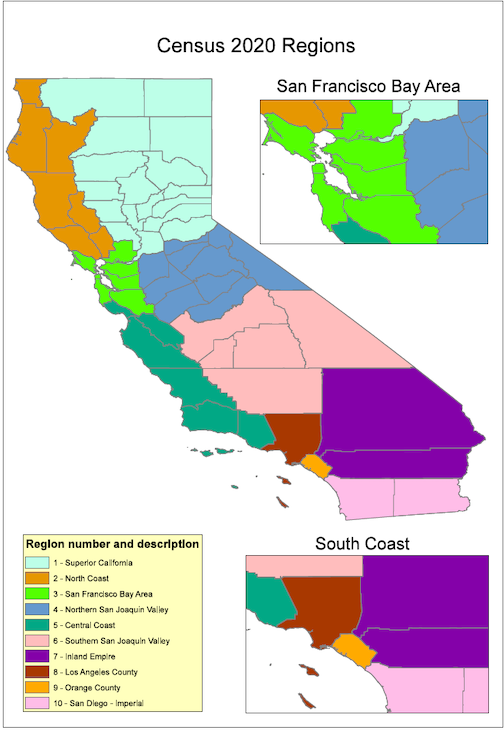

### 👇 Clasificación

En base a la clasificación formal de las principales regiones de California se ha creado un diccionario de regiones identificándolas por su punto central geográfico. De esta manera, podremos identificar la zona para cada registro de nuestro dataset obteniendo su mínima distancia al punto representativo de cada región.

**Diccionario de zonas**

| Región                       | Clave | Definición General                                                                         | Latitud (N) | Longitud (W) |
| ---------------------------- | ----- | ------------------------------------------------------------------------------------------ | ----------- | ------------ |
| Norte de California (NorCal) | 1     | Región costera y boscosa del extremo norte (Eureka, Redding).                              | ≈41.0∘      | −123.5∘      |
| Valle Central                | 2     | La gran región agrícola en el interior (Sacramento, Fresno).                               | ≈37.7∘      | −121.0∘      |
| Sierra Nevada                | 3     | La principal cadena montañosa al este del Valle Central (Yosemite, Mt. Whitney).           | ≈37.8∘      | −119.5∘      |
| Costa Central                | 4     | La región costera entre la Bahía de San Francisco y Los Ángeles (Monterey, Santa Bárbara). | ≈35.5∘      | −120.7∘      |
| Sur de California (SoCal)    | 5     | La región metropolitana y desértica del sur (Los Ángeles, San Diego).                      | ≈34.0∘      | −118.0∘      |

*El siguiente metodo de clasificación es meramente para **fines académicos**, por lo que la clasificación funcionará en base a la zona más cercana sin tomar en cuenta fronteras ni divisiones socio culturales.*

In [16]:
# ------------------------------------------------------------------------------
# CLASIFICANDO REGIONES
# ------------------------------------------------------------------------------
# En base a:
_DICT_REGIONS_ = {
    '1': 'Norte de California (NorCal)',
    '2': 'Valle Central',
    '3': 'Sierra Nevada',
    '4': 'Costa Central',
    '5': 'Sur de California (SoCal)'
}
# 1. Definimos un diccionario de puntos centrales representativos para cada región de California.
# Estas coordenadas sirven como "centroides" para el cálculo de distancia.
# (Latitud, Longitud)
_Region_ = 'Region'
REGIONS = {
    '1': (41.0, -123.5), # Norte del estado
    '2': (37.7, -121.0), # Zona agricola
    '3': (37.8, -119.5), # Zoona de Montaña
    '4': (35.5, -120.7), # Monterey / San Simeon
    '5': (34.0, -118.0)  # El sur: Los Ángeles / San Diego
}

# ------------------------------------------------------------------------------
# funcion euclidean_distance
def euclidean_distance(lat1, lon1, lat2, lon2):
    """Calcula la distancia euclidiana entre dos puntos de coordenadas."""
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

# ------------------------------------------------------------------------------
# funcion para clasificar regiones
def classify_region(row):
    """
    Clasifica un punto de coordenadas (Lat, Long) asignándole la región
    cuyo punto central esté más cerca (distancia euclidiana mínima).
    """
    lat = row['Latitude']
    lon = row['Longitude']

    distances = {}

    # 2. Calculamos la distancia del registro a cada centroide de región
    for region, (r_lat, r_lon) in REGIONS.items():
        distances[region] = euclidean_distance(lat, lon, r_lat, r_lon)

    # 3. Obtenemos la región con la distancia mínima
    return min(distances, key=distances.get)

# ------------------------------------------------------------------------------
# funcion para inicializar el mapeo de regiones
def process_coordinates(df):
    """
    Carga el dataset, clasifica cada coordenada y genera el resultado.
    """
    try:
        # Verificar que las columnas necesarias existan
        if 'Latitude' not in df.columns or 'Longitude' not in df.columns:
            print("Error: El archivo CSV debe contener las columnas 'Latitude' y 'Longitude'.")
            return

        # 4. Aplicamos la clasificación a todo el DataFrame
        print(f"Clasificando {len(df)} registros...")
        df[_Region_] = df.apply(classify_region, axis=1)

        # 5. Devolvemos el resultado
        return df

    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")

# ------------------------------------------------------------------------------
# Ejecutar el procesamiento
df_regiones = process_coordinates(df_limpio)

# Resultado
print("\nClasificación terminada")
df_regiones[_Region_].unique()


Clasificando 20640 registros...

Clasificación terminada


array(['2', '3', '1', '4', '5'], dtype=object)

### ✅ Verificación de la Clasificación

In [17]:
# ------------------------------------------------------------------------------
# ✅ Verfificación de la Clasificación
# ------------------------------------------------------------------------------

# listado de categoricas
_COLUMNAS_CATEGORICAS_ = [_Region_]

# en base a nuestra nueva columna categorica Region
# df_regiones['Region']
# definimos el diccionario de valores unicos
columnas_categoricas = df_regiones[_COLUMNAS_CATEGORICAS_]
# definimos el diccionario de valores unicos
_dict_unique_values_ = {
    _Region_: [],
   'Cantidad': []
}

# recorremos las columnas categoricas para obtener sus valores
print("=" * 80)
print("\033[1m --- Valores únicos por columna categórica: --- \033[0m")
print("=" * 80)
for col in columnas_categoricas.columns:
    # obtenemos los vals unicos
    unique_values = columnas_categoricas[col].unique()
    # asignamos los valores unicos al dict
    _dict_unique_values_[col] = columnas_categoricas[col].unique()
    aux = df_regiones[col].value_counts()

    for reg in columnas_categoricas[col].unique():
      _dict_unique_values_['Cantidad'].append(aux[reg])

# para mostrar el resultado del diccionario en pantalla
# convertimos el diccionario a un conjunto de listas
data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

# definimos los titulos de la tabla
headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
# imprimiendo
print(tabulate(data, headers=headers, tablefmt="grid"))

 --- Valores únicos por columna categórica: --- 
+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Columna   |   Valor único 1 |   Valor único 2 |   Valor único 3 |   Valor único 4 |   Valor único 5 |
+===========+=================+=================+=================+=================+=================+
| Region    |               2 |               3 |               1 |               4 |               5 |
+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+
| Cantidad  |            7106 |             893 |             603 |             842 |           11196 |
+-----------+-----------------+-----------------+-----------------+-----------------+-----------------+


### ⚠️ Implicación de las regiones

Aunque nuestro modelo será de regresión para predecir el valor promedio de la vivienda en California, la distribución de los datos geográficos tiene una implicación de dominio geográfico: Las regiones de Sur de California y Valle Central dominan el conjunto de datos, representando la gran mayoría de las observaciones, y esto se asemeja conla realidad, pues son las zonas con mayor población del estado.

| Región              | Clave | Conteo de Registros | Proporción Aproximada |
| ------------------- | ----- | ------------------- | --------------------- |
| Sur de California   | 5     | 11,196              | Mayoritaria           |
| Valle Central       | 2     | 7,106               | Secundaria            |
| Sierra Nevada       | 3     | 893                 | Minoritaria           |
| Costa Central       | 4     | 842                 | Minoritaria           |
| Norte de California | 1     | 603                 | Minoritaria           |
| ------------------- | ----- | ------------------- | --------------------- |
| TOTAL               | --    | 20,640              | 100%                  |

## ⚙️ Transformación y Normalización de Variables

A continuación, se procederá a transformar las variables para hacerlas útiles para el análisis y modelado.

### ✔ 1. Codificación de variables categóricas

Los modelos de machine learning no pueden procesar variables categóricas directamente, es por ello que en el paso de **Regiones de California** se realizó una codificación en formato numérico para cada región.

In [18]:
df_regiones[_Region_] = df_regiones[_Region_].astype(int)
print(df_regiones.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
Region           int64
dtype: object


Una vez definidas nuestras 5 regiones, procederemos a crear un One-Hot Encoding para cada región.

### ✔ 2. Codificación geográfica de las regiones 🌎

In [19]:
# ----------------------------------------------------------------------
# Aplicamos One-Hot Encoding a cada region
# ----------------------------------------------------------------------

# copia
df_modelado = df_regiones.copy()

# One-Hot Encoding en 'Region'
df_encoded = pd.get_dummies(df_modelado, columns=[_Region_], drop_first=False)

# columna original 'Region'
df_encoded[_Region_] = df_regiones[_Region_]

# verificando
print("=" * 80)
print("\033[1m --- Columnas creadas por One-Hot Encoding --- \033[0m")
print("=" * 80)
print([col for col in df_encoded.columns if 'Region' in col])

 --- Columnas creadas por One-Hot Encoding --- 
['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region']


In [20]:
print("=" * 80)
print("\033[1m ---DataFrame codificado --- \033[0m")
print("=" * 80)
df_encoded.tail(500)

 ---DataFrame codificado --- 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Region_1,Region_2,Region_3,Region_4,Region_5,Region
20140,5.3582,35.0,4.812500,0.937500,334.0,3.479167,34.34,-119.04,2.813,False,False,False,False,True,5
20141,2.7951,52.0,4.634868,1.180921,981.0,3.226974,34.36,-119.06,1.993,False,False,False,False,True,5
20142,1.8618,52.0,4.157718,1.073826,934.0,3.134228,34.36,-119.06,1.833,False,False,False,False,True,5
20143,2.0682,34.0,3.844691,1.023772,2116.0,3.353407,34.35,-119.06,1.583,False,False,False,False,True,5
20144,2.2443,39.0,3.044872,0.961538,1366.0,4.378205,34.35,-119.05,1.466,False,False,False,False,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,False,True,False,False,False,2
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,False,True,False,False,False,2
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,False,True,False,False,False,2
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,False,True,False,False,False,2


**Recodificación completa**

Hecho esto, nuestras variables están mejor codificadas y hemos creados nuevas variables geográficas.

### ✔ 3. Estandarización de variables numéricas

Las variables **númericas** serán normalizadas para evitar que afecten negativamente a los modelos de aprendizaje.

La normalización escalará los valores a un rango entre 0 y 1, lo que asegurará que todos los datos tengan el mismo peso en el análisis.

Estas variables serán consideradas como parte de las variables independientes, por otro lado, nuestra variable objetivo **Promedio del Costo de Vivienda** no será normalizada. Mantendrá su escala original para que el MAE y los coeficientes sean directamente interpretables en términos monetarios reales.

In [21]:
# ------------------------------------------------------------------------------
# ✔ Estandarización de variables numéricas
# ------------------------------------------------------------------------------
# copia
df_limpio_encoded = df_encoded.copy()

# columnas del DataFrame
columnas_totales = df_limpio_encoded.columns.tolist()

# Variable Objetivo
target_col = _MedHouseVal_
y = df_limpio_encoded[target_col]

# Tomamos las Variables Predictoras
# Y excluimos la columna objetivo, Latitud/Longitud, y la columna Región.
columnas_a_excluir = [target_col, _Latitude_, _Longitude_, _Region_]
columnas_X = [col for col in columnas_totales if col not in columnas_a_excluir]

# todas las características
X = df_limpio_encoded[columnas_X]

# Train/Test antes de escalar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# escalando variables
# columnas numéricas (sin las dummies de la región)
columnas_numericas = [_MedInc_, _HouseAge_, _AveRooms_, _AveBedrms_, _Population_, _AveOccup_]
columnas_dummies = [col for col in X_train.columns if 'Region_' in col]

# escalador
scaler = StandardScaler()

# fit_transform en el entrenamiento
X_train_scaled_values = scaler.fit_transform(X_train[columnas_numericas])

# transform en el conjunto de prueba
X_test_scaled_values = scaler.transform(X_test[columnas_numericas])


# DataFrames con las variables numéricas escaladas
# entrenamiento
X_train_scaled_num = pd.DataFrame(
    X_train_scaled_values,
    columns=columnas_numericas,
    index=X_train.index
)

# pruebas
X_test_scaled_num = pd.DataFrame(
    X_test_scaled_values,
    columns=columnas_numericas,
    index=X_test.index
)

# volvemos a unir a las variables de regiones
X_train_final = pd.concat(
    [X_train_scaled_num, X_train[columnas_dummies]], axis=1
)
X_test_final = pd.concat(
    [X_test_scaled_num, X_test[columnas_dummies]], axis=1
)

print("=" * 80)
print("\033[1m---- Preparación de datos completada ---\033[0m")
print("=" * 80)
X_train_final.head(500)

---- Preparación de datos completada ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Region_1,Region_2,Region_3,Region_4,Region_5
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,False,False,False,False,True
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,False,False,False,False,True
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,False,False,False,True,False
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,False,False,False,False,True
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
7476,-0.715381,0.586545,-0.585576,0.168067,-0.205320,0.081799,False,False,False,False,True
9842,-0.529375,0.348490,-0.561468,-0.038822,-0.169261,-0.090143,False,True,False,False,False
4614,-1.027054,1.142008,-1.295050,-0.150607,2.193051,-0.007844,False,False,False,False,True
12833,-0.124908,-0.048268,-0.077935,-0.200481,-0.508744,-0.027347,False,True,False,False,False


Al momento nos hemos asegurado de tener un dataset limpio y libre de registros nulos y duplicados, a su vez, se han realizado diversas transformaciones:
1. **Codificación de variables categóricas**
2. **Codificación geográfica de regiones**
3. **Estandarización de variables numéricas**

Con estas transformaciones, nuestro dataset está limpio y enriquecido.

## ✔ Estructura del Dataset limpio

In [22]:
print("=" * 80)
print("\033[1m --- Dataset origingal limpiado correctamente --- \033[0m")
print("=" * 80)
print(f"Número de filas: {df_limpio.shape[0]}")
print(f"Número de columnas: {df_limpio.shape[1]}")

 --- Dataset origingal limpiado correctamente --- 
Número de filas: 20640
Número de columnas: 10


In [23]:
print("=" * 80)
print("\033[1m --- Dataset escalado y entrenado correctamente --- \033[0m")
print("=" * 80)
print(f"Número de filas: {X_train_final.shape[0]}")
print(f"Número de columnas: {X_train_final.shape[1]}")

 --- Dataset escalado y entrenado correctamente --- 
Número de filas: 16512
Número de columnas: 11


In [24]:
print("=" * 80)
print("\033[1m --- Dataset de pruebas --- \033[0m")
print("=" * 80)
print(f"Número de filas: {X_test_final.shape[0]}")
print(f"Número de columnas: {X_test_final.shape[1]}")

 --- Dataset de pruebas --- 
Número de filas: 4128
Número de columnas: 11


## 🗂 Resumen de la estructura del Dataset limpio

| Columna                               | Tipo de Variable   | Descripción Clave                                                         | Uso en el Modelo     |
| ------------------------------------- | ------------------ | ------------------------------------------------------------------------- | -------------------- |
| MedInc                                | Numérica           | Ingresos Medios en el grupo de manzanas (en decenas de miles de dólares). | Predictora (X)       |
| HouseAge                              | Numérica           | Edad media de las viviendas en el grupo de manzanas.                      | Predictora (X)       |
| AveRooms                              | Numérica           | Número promedio de habitaciones por hogar.                                | Predictora (X)       |
| AveBedrms                             | Numérica           | Número promedio de dormitorios por hogar.                                 | Predictora (X)       |
| Population                            | Numérica           | Población total del grupo de manzanas.                                    | Predictora (X)       |
| AveOccup                              | Numérica           | Número promedio de miembros del hogar (ocupación).                        | Predictora (X)       |
| Latitude                              | Numérica           | Latitud geográfica.                                                       | Predictora (X)       |
| Longitude                             | Numérica           | Longitud geográfica.                                                      | Predictora (X)       |
| MedHouseValue                         | Numérica           | Valor Promedio de la Casa (en cientos de miles de dólares).               | Objetivo (y)         |
| Region                       | Categórica (entero) | Columna nueva de la región.                                   | Referencia/Exclusión |
| Region_...(1-5) | Binaria (0 ó 1)    | Variables Dummy creadas por One-Hot Encoding para cada región.            | Predictora (X)       |

In [25]:
df_limpio_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
 9   Region_1     20640 non-null  bool   
 10  Region_2     20640 non-null  bool   
 11  Region_3     20640 non-null  bool   
 12  Region_4     20640 non-null  bool   
 13  Region_5     20640 non-null  bool   
 14  Region       20640 non-null  int64  
dtypes: bool(5), float64(9), int64(1)
memory usage: 1.7 MB


A partir del proceso de limpieza y transformación aplicado, el dataset es ahora más confiable para los procesos de aprendizaje.

# 💻 Análisis Exploratorio de Datos (EDA).

Ahora que nuestro dataset está limpio y preparado, podemos pasar por la fase de Análisis Exploratorio de Datos. Aquí se incluirán algunas visualizaciones clave para descubrir patrones, tendencias y anomalías relevantes antes de pasar a la creación de los modelos de regresión.

La visualización de la distribución de las variables principales nos ayudará a entender la estructura de los datos y justificar las próximas decisiones para los modelos.

## 🔍 Análisis preliminar

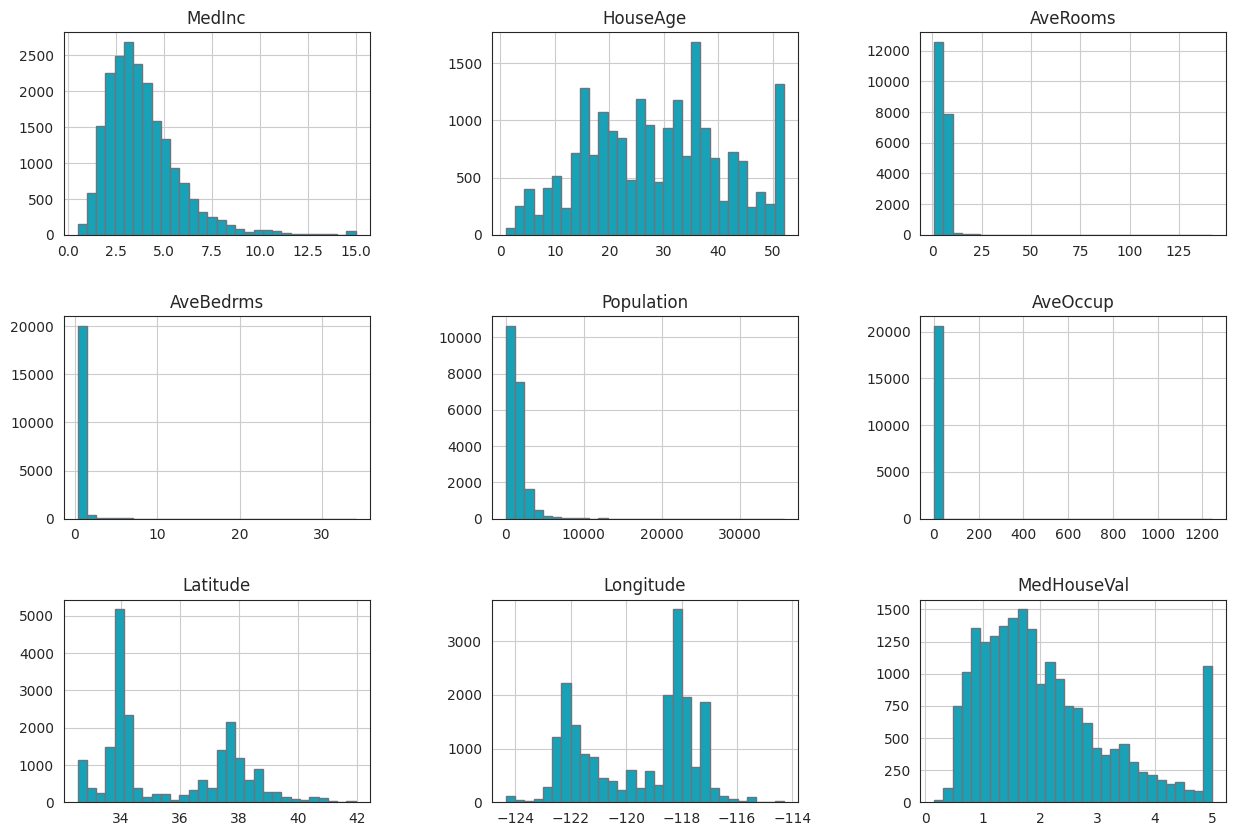

In [26]:
housing.frame.hist(
    figsize=(15, 10),
    bins=30,
    color=_color_info,
    edgecolor=_color_gray)
plt.subplots_adjust(hspace=0.4, wspace=0.4)

**Obersvaciones preliminares**

A primera instancia se observa que:
-  El salario de las personas, indicado por **MedInc** se distribuye más o menos normalmente y algunas personas tienen un salario más alto.
- La edad de la vivienda, indicada por **HouseAge** tiene una distribución más o menos uniforme.
- En cuanto a las características, AveRooms, AveBedrms, AveOccupancy, Population, se aprecia que tenemos la mayor concentración en los valores medios y es posible la existencia de muchos valores atipicos.
- En cuanto al objetivo, **MedHouseVal** tiene una distribución de cola larga, además de indicar una frecuencia muy alta de altos costos al final.

## 📊 Visualización 1: Distribución de los Ingresos Medios por grupos

Se analiza la Distribución de los Ingresos Medios ya que considero puede ser la variable predictora más importante para el valor de la vivienda.

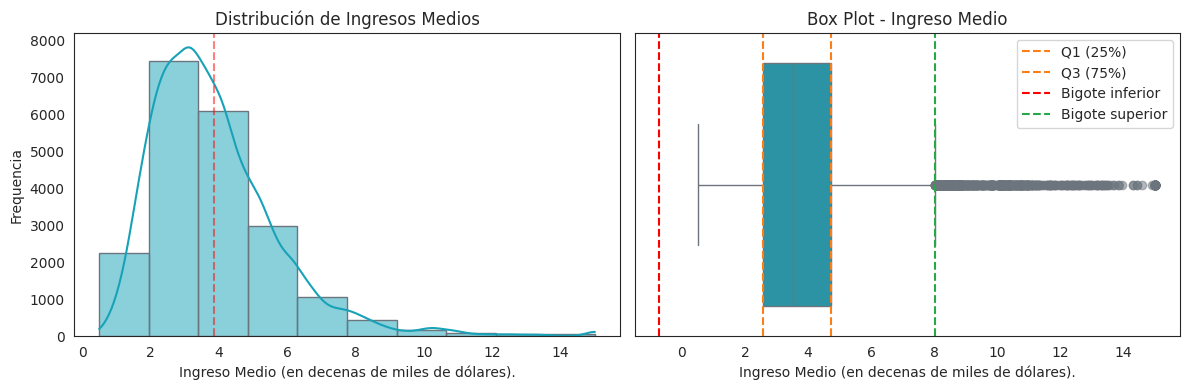

--------------------------------------------------------------------------------
 --- Estadisticas por Ingreso Medio --- 
--------------------------------------------------------------------------------
┌─────────┬──────┬─────┬─────┬──────┬──────┬──────┬──────┐
│ count   │ mean │ std │ min │ 25%  │ 50%  │ 75%  │ max  │
├─────────┼──────┼─────┼─────┼──────┼──────┼──────┼──────┤
│ 20640.0 │ 3.87 │ 1.9 │ 0.5 │ 2.56 │ 3.53 │ 4.74 │ 15.0 │
└─────────┴──────┴─────┴─────┴──────┴──────┴──────┴──────┘


In [27]:
# ------------------------------------------------------------------------------
# Distribución de los Ingresos Medios por grupos
# ------------------------------------------------------------------------------
outlier_properties = dict(markerfacecolor=_color_gray, alpha=0.5)

plt.figure(figsize=(12, 4))
# subplot uno para histograma
plt1 = plt.subplot(1, 2, 1)
# histograma
at = sns.histplot(
    data=df_limpio,
    x= _MedInc_,
    color=_color_info,
    edgecolor=_color_gray,
    bins=10,
    kde=True,
    shrink=1
)

# línea vertical en la media
plt.axvline(df_limpio[_MedInc_].mean(), color=_color_danger, linestyle='--', alpha=0.5)

# titulos
plt.title('Distribución de Ingresos Medios')
plt.xlabel('Ingreso Medio (en decenas de miles de dólares).')
plt.ylabel('Frequencia')

# ------------------------------------------------------------------------------
# plot dos para boxplot
plt2 = plt.subplot(1, 2, 2)

# boxplot
ax2 = sns.boxplot(
    x=df_limpio[_MedInc_],
    color=_color_info,
    linecolor=_color_gray,
    flierprops=outlier_properties
)

# calculamos valores estadísticos
q1 = df_limpio[_MedInc_].quantile(0.25)
q3 = df_limpio[_MedInc_].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# anotaciones y limites
plt2.axvline(q1, color=_color_orange, linestyle="--", label="Q1 (25%)")
plt2.axvline(q3, color=_color_orange, linestyle="--", label="Q3 (75%)")
plt2.axvline(lower_whisker, color=_color_danger, linestyle="--", label="Bigote inferior")
plt2.axvline(upper_whisker, color=_color_success, linestyle="--", label="Bigote superior")

# ------------------------------------------------------------------------------
# titulos
plt.title('Box Plot - Ingreso Medio')
plt.xlabel('Ingreso Medio (en decenas de miles de dólares).')
# show
plt.tight_layout()
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# información general
print("-" * 80)
print("\033[1m --- Estadisticas por Ingreso Medio --- \033[0m")
print("-" * 80)
# imprimimos las estadisticas de Ingreso Medio utilizando el formato de 'tabulate'
print(tabulate(
    df_limpio[_MedInc_].describe().round(decimals=2).reset_index().transpose(),
    tablefmt="simple_grid",
    showindex="never",
    )
)

### 📑 Interpretación

**Distribución de los Ingresos Medios**

- La distribución de los Ingresos Medios se presenta sesgada hacia la derecha.
- La gran mayoría de los grupos de manzanas se concentra en los rangos de ingresos bajos a moderados, específicamente entre 2 y 4 respectivamente.
- Existe una larga lista de grupos de manzanas con ingresos muy altos que se extiende hasta el valor máximo de 15, que en terminos monetarios representaría $150,000$.
- En la gráfica de Box Plot podemos ver como los valores atipicos se extienden más halla de los $80,000$
- Este fuerte sesgo es una justificación para la estandarización que ya se realizó.

## 📊 Visualización 2: Distribución de Viviendas por Regiones

Se generan las gráficas para la distribución de la variable categórica de regiones (nueva).

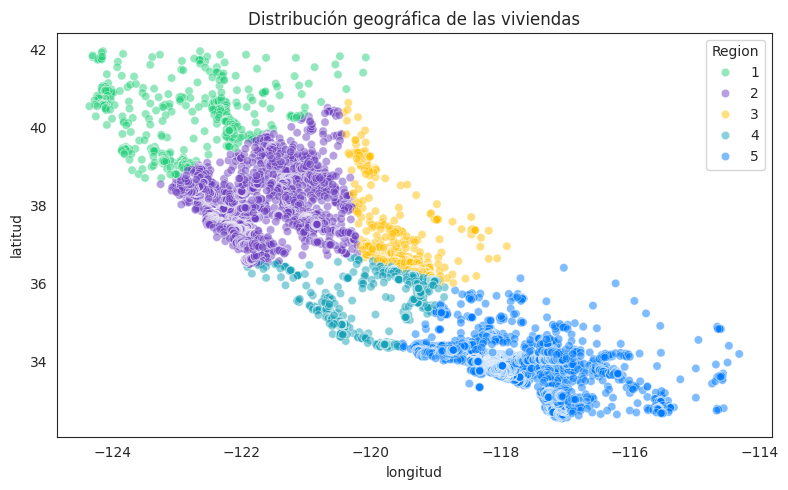

+------------------------------+---------------+---------------+---------------+---------------------------+
| Región 1                     | Región 2      | Región 3      | Región 4      | Región 5                  |
+==============================+===============+===============+===============+===========================+
| Norte de California (NorCal) | Valle Central | Sierra Nevada | Costa Central | Sur de California (SoCal) |
+------------------------------+---------------+---------------+---------------+---------------------------+


In [28]:
# ------------------------------------------------------------------------------
# grafica de Distribución general de regiones por coordenadas
# ------------------------------------------------------------------------------
longitudes = df_limpio[_Longitude_].copy()
latitudes = df_limpio[_Latitude_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(8, 5))

# puntos por coordenadas
sns.scatterplot(
    data=df_limpio,
    x=longitudes,
    y=latitudes,
    hue=_Region_,
    palette=_paleta_tecmi,
    alpha=0.5,
)

# titulos
plt.title('Distribución geográfica de las viviendas')
plt.xlabel('longitud')
plt.ylabel('latitud')

# ------------------------------------------------------------------------------
# show
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# diccionario
# convertimos el diccionario a un conjunto de listas
data = [value for key, value in _DICT_REGIONS_.items()]

headers = [f"Región {i+1}" for i in range(0, len(data))]
print(tabulate([data], headers=headers, tablefmt="grid"))

**Con esta distribución podemos comprobar que el cálculo de variables geograficas fue correcto. Notecé el parecido al mapa real del estado de California**

La gran mayoría de las viviendas se concentran a lo largo de la costa de California, lo cual es muy realista. Tenemos una alta densidad de puntos en el Sur de California y en el Área del Valle.

La creación de la variable categórica Region fue una decisión muy acertada para interpretar esta distribución. Sin embargo, la distribución nos dice que el modelo tendrá un alto rendimiento predictivo para los mercados de mayor población, pero su capacidad de predecir en zonas geográficas menos densas será menos eficiente.

#### 📊 Distribución de regiones

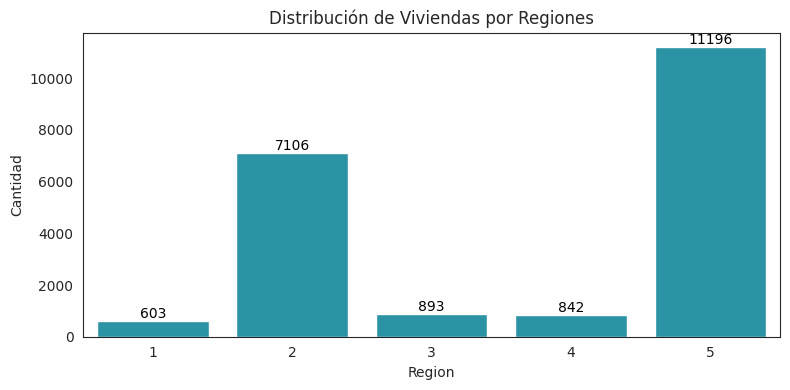

+------------------------------+---------------+---------------+---------------+---------------------------+
| Región 1                     | Región 2      | Región 3      | Región 4      | Región 5                  |
+==============================+===============+===============+===============+===========================+
| Norte de California (NorCal) | Valle Central | Sierra Nevada | Costa Central | Sur de California (SoCal) |
+------------------------------+---------------+---------------+---------------+---------------------------+
| 603                          | 7106          | 893           | 842           | 11196                     |
+------------------------------+---------------+---------------+---------------+---------------------------+


In [29]:
# ------------------------------------------------------------------------------
# distribucion de regiones
# ------------------------------------------------------------------------------

plt.figure(figsize=(8, 4))

# agrupacion y conteo de regiones
count_data = df_limpio[_Region_].value_counts().reset_index().copy()
x_data = count_data[_Region_]
y_data = count_data['count']

# creando la grafica de barras
ax = sns.barplot(
    data=count_data,
    x=x_data,
    y=y_data,
    color=_color_info)

# valores en las barras
for index, row in count_data.iterrows():
    plt.text(int(row['Region']-1), int(row['count']), row['count'], color='black', ha="center", va='bottom', fontsize=10)

# titulos
plt.title('Distribución de Viviendas por Regiones')
plt.xlabel('Region')
plt.ylabel('Cantidad')

# ------------------------------------------------------------------------------
# show
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# diccionario
# para mostrar el resultado del diccionario en pantalla
# convertimos el diccionario a un conjunto de listas
data = [value for key, value in _DICT_REGIONS_.items()]

aux = np.random.randint(0, 5, 5)
for index, row in count_data.iterrows():
  aux[int(row['Region'])-1] = row['count']

headers = [f"Región {i+1}" for i in range(0, len(data))]
print(tabulate([data, aux], headers=headers, tablefmt="grid"))




### 📑 Interpretación

**Análisis de la Distribución de Viviendas por Regiones**

La distribución de las viviendas por región se muestra muy desbalanceada, lo cual podría tener implicaciones directas para el modelado:

- La región de Sur de California es la region dominante, concentrando más del 50% de todos los grupos de manzanas.
- El Valle Central es la segunda región más grande, pero con una cantidad significativamente menor que el Sur.
- Las regiones de Norte de California, Costa Central y Sierra Nevada son regiones minoritarias con muy pocos registros, menos de 1,000 cada una.


*Si se aplica un modelo de regresión individual para cada Region, este tendrá un buen desempeño de los precios en el Sur de California y el Valle Central. Pero no ocurrira lo mismo en las regiones menos habitadas debido a la escacez de datos.*

## 📊 Visualización 3: Distribución del Costo Medio de la Vivienda

Se analizará la distribución de la variable del Costo Medio de la Vivienda para entender su estructura, posibles sesgos y la presencia de valores atípicos.

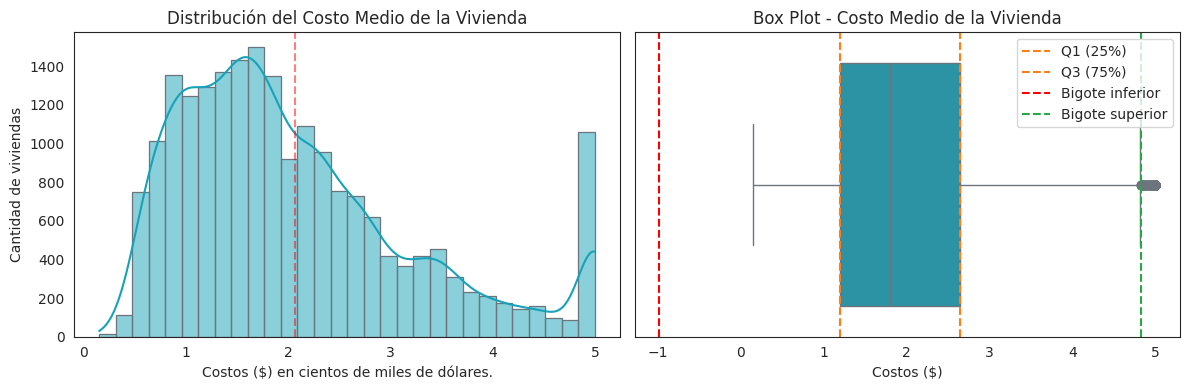

--------------------------------------------------------------------------------
 --- Estadisticas del Costo Medio de la Vivienda --- 
--------------------------------------------------------------------------------
┌─────────┬──────┬──────┬──────┬─────┬─────┬──────┬─────┐
│ count   │ mean │ std  │ min  │ 25% │ 50% │ 75%  │ max │
├─────────┼──────┼──────┼──────┼─────┼─────┼──────┼─────┤
│ 20640.0 │ 2.07 │ 1.15 │ 0.15 │ 1.2 │ 1.8 │ 2.65 │ 5.0 │
└─────────┴──────┴──────┴──────┴─────┴─────┴──────┴─────┘


In [30]:
# ------------------------------------------------------------------------------
# grafica de Distribución del Costo Medio de la Vivienda
# ------------------------------------------------------------------------------
costos = df_limpio[_MedHouseVal_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(12, 4))
# subplot uno para histograma
plt1 = plt.subplot(1, 2, 1)
# histograma
at = sns.histplot(
    x=costos,
    color=_color_info,
    edgecolor=_color_gray,
    bins=30,
    kde=True,
    shrink=1
)

# línea vertical en la media
plt.axvline(df_limpio[_MedHouseVal_].mean(), color=_color_danger, linestyle='--', alpha=0.5)

# titulos
plt.title('Distribución del Costo Medio de la Vivienda')
plt.xlabel('Costos ($) en cientos de miles de dólares.')
plt.ylabel('Cantidad de viviendas')

# ------------------------------------------------------------------------------
# plot dos para boxplot
plt2 = plt.subplot(1, 2, 2)

# boxplot
ax2 = sns.boxplot(
    x=costos,
    color=_color_info,
    linecolor=_color_gray,
    flierprops=outlier_properties
)

# calculamos valores estadísticos
q1 = costos.quantile(0.25)
q3 = costos.quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5 * iqr
upper_whisker = q3 + 1.5 * iqr

# anotaciones y limites
plt2.axvline(q1, color=_color_orange, linestyle="--", label="Q1 (25%)")
plt2.axvline(q3, color=_color_orange, linestyle="--", label="Q3 (75%)")
plt2.axvline(lower_whisker, color=_color_danger, linestyle="--", label="Bigote inferior")
plt2.axvline(upper_whisker, color=_color_success, linestyle="--", label="Bigote superior")
# titulos
plt.title('Box Plot - Costo Medio de la Vivienda')
plt.xlabel('Costos ($)')
# show
plt.tight_layout()
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# información general
print("-" * 80)
print("\033[1m --- Estadisticas del Costo Medio de la Vivienda --- \033[0m")
print("-" * 80)
# imprimimos las estadisticas de edad utilizando el formato de 'tabulate'
print(tabulate(
    costos.describe().round(decimals=2).reset_index().transpose(),
    tablefmt="simple_grid",
    showindex="never",
    )
)

### 📑 Interpretación

**Análisis de la Distribución del Costo Medio de la Vivienda**


En esta distribución del valor medio de la vivienda en California podemos observar:
- La mayoría de los valores medios de vivienda están concentrados en los rangos bajo a medio, alrededor de $150,000$ a $250,000$ dolares. La lista de valores se extiende hacia valores más altos, indicando que tenemos menos áreas con propiedades de muy alto valor.
- Tenemos una alta concentración de registros en el valor máximo de $500,000$.


En base a estos valores de entrenamiento, el modelo de regresión tendrá un límite de predicción en $500,000. Y no podrá predecir valores superiores a 5.0 afectando a los grupos de manzanas de ingresos muy altos.

**Necesidad de ajuste de la variable objetivo**

La lista larga de altos costos sugieren que una transformación de la variable objetivo podría mejorar el rendimiento de los modelos lineales al hacer la distribución más normal. Sin embargo, en modelos basados en árboles, como Random Forest, esto sería menos problemático.



## 📊 Visualización 4: Distribución de las variables de Características de las Viviendas

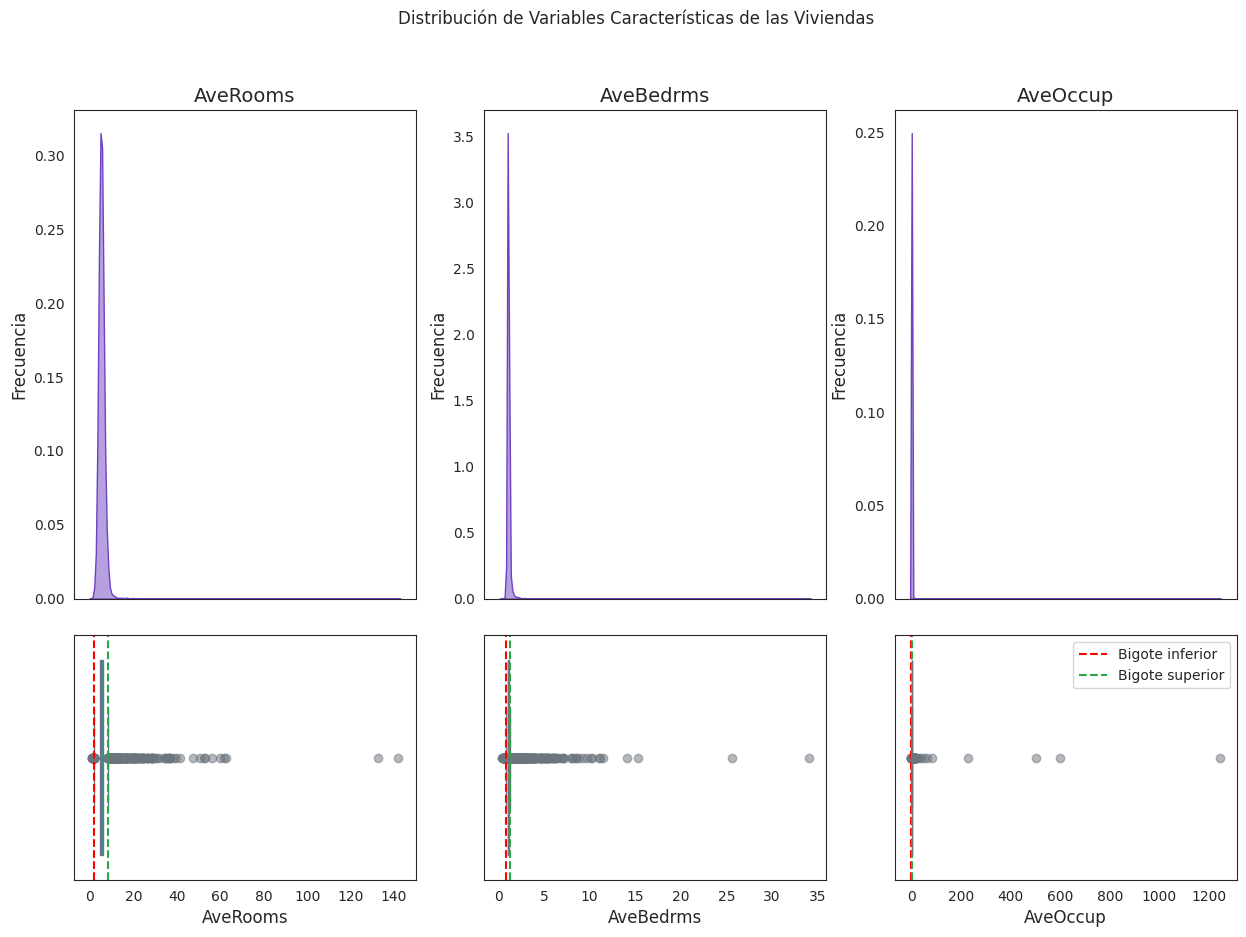

In [31]:
# ------------------------------------------------------------------------------
# Visualización 4: Distribución de las variables de Características de las Viviendas
# ------------------------------------------------------------------------------

# variables características
variables_hogar = ['AveRooms', 'AveBedrms', 'AveOccup']

# plot con 2 filas y 3 columnas, compartiendo el eje x en el histograma y boxplot
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10),
    sharex='col',
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.1}
)

fig.suptitle('Distribución de Variables Características de las Viviendas')

# loop sobre las variables características
for i, col in enumerate(variables_hogar):

    costos = df_limpio[col].copy()

    # --------------------------------------------------------------------------
    # histogramas
    at = sns.kdeplot(
        costos,
        color=_color_purple,
        alpha=0.5,
        fill=True,
        ax=axes[0, i]
    )

    # titulos
    axes[0, i].set_title(col, fontsize=14)
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel('Frecuencia', fontsize=12)

    # --------------------------------------------------------------------------
    # Box Plots
    bx = sns.boxplot(
        x=costos,
        color=_color_info,
        linecolor=_color_gray,
        ax=axes[1, i],
        flierprops=outlier_properties
    )

    # calculamos valores estadísticos
    q1 = costos.quantile(0.25)
    q3 = costos.quantile(0.75)
    iqr = q3 - q1
    lower_whisker = q1 - 1.5 * iqr
    upper_whisker = q3 + 1.5 * iqr

    # anotaciones y limites
    bx.axvline(lower_whisker, color=_color_danger, linestyle="--", label="Bigote inferior")
    bx.axvline(upper_whisker, color=_color_success, linestyle="--", label="Bigote superior")

    axes[1, i].set_xlabel(col, fontsize=12)
    axes[1, i].set_yticks([])

# ------------------------------------------------------------------------------
# show
plt.tight_layout()
plt.legend()
plt.show()

### 📑 Interpretación

En esta gráfica se combina el histograma y el box plot para las variables AveRooms, AveBedrms y AveOccup para comprender la distribución de las variables caracteristicas.

A primera vista podemos observar que las tres variables de características de las viviendas presentan un patrón común de fuerte concentración en valores bajos y una alta presencia de valores atipicos, lo cual afecta la media de cada distribución.

- Las tres distribuciones son fuertemente asimétricas y sesgadas a la derecha. Esto indica que la inmensa mayoría de los grupos de manzanas tienen valores bajos para el número promedio de habitaciones, dormitorios, y miembros por hogar.

- AveRooms y AveBedrms: Muestran una gran cantidad de puntos atípicos por encima del rango de los bigotes superiores. Esto sugiere que hay grupos de manzanas con casas que tienen un número muy alto de habitaciones y dormitorios en promedio.

- AveOccup: Esta variable presenta valores atípicos que llegan a magnitudes muy altas, representando un promedio ocupacional por vivienda poco común.


La presencia de valores atipicos muy altos, en estas tres variables es una fuerte justificación para el uso de modelos de regresión como Random Forest. En caso de implementarse una Regresión Lineal, sería necesario considerar la transformación de estas variables para reducir el impacto de los outliers.

## 📊 Distribuciones geográficas

A continuación se presentan una serie de distribuciones geográficas para entender de mejor manerá la distribución de costos de la vivienda en el estado de California.

### 📊 Distribución geográfica de costos de vivienda

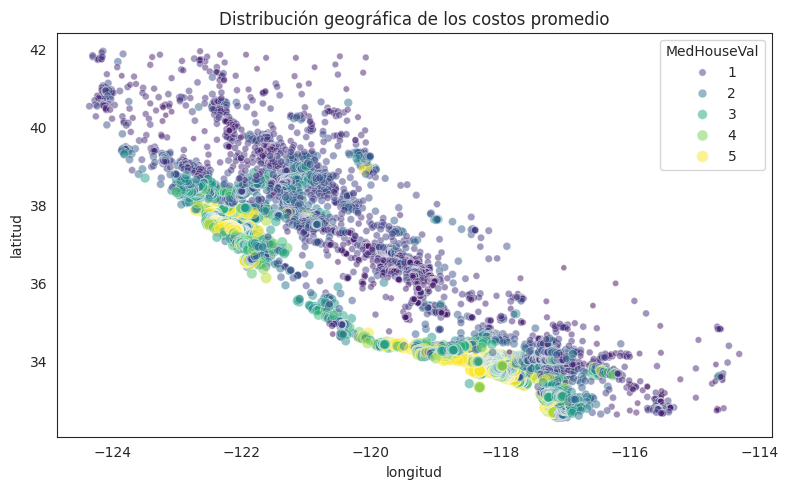

In [32]:
# ------------------------------------------------------------------------------
# grafica de Distribución de costos por coordenadas
# ------------------------------------------------------------------------------
longitudes = df_limpio[_Longitude_].copy()
latitudes = df_limpio[_Latitude_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(8, 5))

# scatter
sns.scatterplot(
    data=df_limpio,
    x=longitudes,
    y=latitudes,
    size=_MedHouseVal_,
    hue=_MedHouseVal_,
    palette="viridis",
    alpha=0.5
)

# ------------------------------------------------------------------------------
# titulos
plt.title('Distribución geográfica de los costos promedio')
plt.xlabel('longitud')
plt.ylabel('latitud')
# show
plt.tight_layout()
plt.show()

#### 📑 Interpretación

La gráfica actúa como un mapa de calor de precios, confirmando que la ubicación es un predictor fundamental del valor de la vivienda:

- Los grupos de manzanas con el valor medio de vivienda más alto están concentrados en las zonas costeras y urbanas. Se observa una fuerte concentración de precios altos en la región de la Bahía de San Francisco y en el área de los Los Ángeles, ajustandecé a la realidad.

- Las zonas con los precios más bajos se encuentran predominantemente en el Valle Central y las regiones interiores del estado.

- La clara segmentación de precios por área geográfica justifica completamente la creación de la variable categórica Region. El modelo de regresión no podría aprender esta compleja relación geográfica solo con las coordenadas, pero sí puede capturar el efecto promedio de alto valor de pertenecer a una región costera codificada.

- La gran cantidad de viviendas de alto valor a lo largo de las costas indica que el modelo debe aprender que los precios máximos se encuentran exclusivamente en estas áreas geográficas.

### 📊 Distribución geográfica poblacional

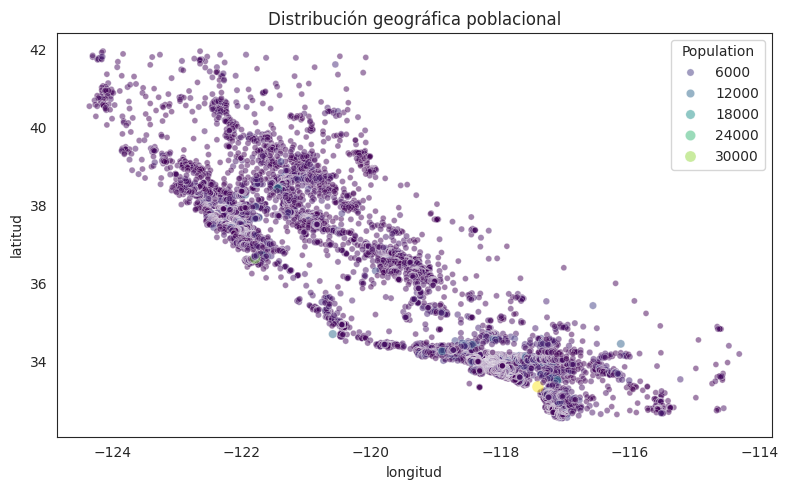

In [33]:
# ------------------------------------------------------------------------------
# grafica de Distribución poblacional
# ------------------------------------------------------------------------------
longitudes = df_limpio[_Longitude_].copy()
latitudes = df_limpio[_Latitude_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(8, 5))

# scatter
sns.scatterplot(
    data=df_limpio,
    x=longitudes,
    y=latitudes,
    size=_Population_,
    hue=_Population_,
    palette="viridis",
    alpha=0.5
)

# ------------------------------------------------------------------------------
# titulos
plt.title('Distribución geográfica poblacional')
plt.xlabel('longitud')
plt.ylabel('latitud')

# show
plt.tight_layout()
plt.show()

#### 📑 Interpretación

La visualización confirma que los grupos de manzanas con mayor población están bien ubicados, y se ajsutan a la realidad de California:

- Los puntos de mayor tamaño se encuentran mayormente en las áreas costeras y en los principales centros urbanos. Esto es evidente en el Sur de California y en la Región de la Bahía. Estos son los mercados inmobiliarios más activos.

- Al comparar esta gráfica con la de precios, se observa que las áreas con alta población tienden a coincidir con las áreas de alto valor. Esto confirma una correlación directa entre la demanda y el precio en las zonas densamente pobladas.

- Las zonas con población más pequeña se extienden a lo largo del Valle Central y las regiones montañosas, lo que indica que el modelo tendrá menos datos para aprender las dinámicas de precios en estos grupos de manzanas con menor densidad demográfica.

La variable Population parece ser una variable muy importante, y en el modelo de regresión la podremos utilizar para capturar el efecto de la demanda.

### 📊 Distribución geográfica de ingresos promedio

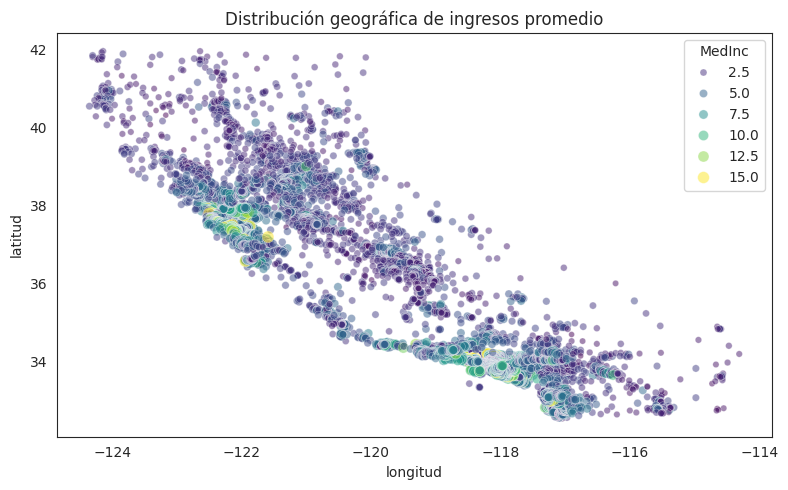

In [34]:
# ------------------------------------------------------------------------------
# grafica de Distribución geográfica de ingresos promedio
# ------------------------------------------------------------------------------
longitudes = df_limpio[_Longitude_].copy()
latitudes = df_limpio[_Latitude_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(8, 5))

# scatter
sns.scatterplot(
    data=df_limpio,
    x=longitudes,
    y=latitudes,
    size=_MedInc_,
    hue=_MedInc_,
    palette="viridis",
    alpha=0.5,
)

# ------------------------------------------------------------------------------
# titulos
plt.title('Distribución geográfica de ingresos promedio')
plt.xlabel('longitud')
plt.ylabel('latitud')

# show
plt.tight_layout()
plt.show()

#### 📑 Interpretación

La visualización actúa como un mapa de calor de ingresos y confirma que la economía costera y urbana es parte de las variables que afectan el alto valor de la vivienda:

- Los grupos de manzanas con los ingresos más altos se concentran casi exclusivamente a lo largo de las áreas costeras del estado, especialmente en la Región de San Francisco, Silicon Valley y en el Sur de California en Los Ángeles y San Diego.

- Esta distribución geográfica de ingresos promedio es prácticamente idéntica a la distribución de precios de las viviendas. Esto confirma que MedInc es un predictor muy influyente; y se deduce que, donde los ingresos son altos, el valor de la vivienda es alto.

- Las zonas con ingresos más bajos se encuentran mayoritariamente en el Valle Central y las zonas rurales.

La variable MedInc será muy importante para el modelo de regresión. El modelo podrá aprender que una ubicación específica con un alto ingreso medio resultará casi siempre en la predicción de un alto valor de vivienda, lo que garantiza un buen $\text{R}^2$ en el modelo final.

### 📊 Distribución geográfica de ingresos promedio contra el valor de la vivienda

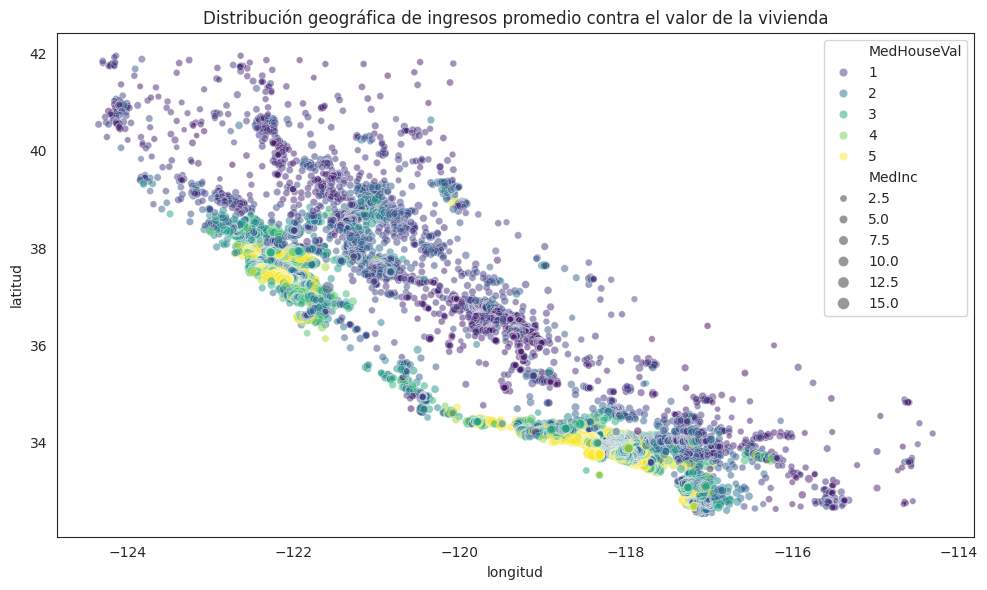

In [35]:
# ------------------------------------------------------------------------------
# grafica de Distribución de costos por coordenadas
# ------------------------------------------------------------------------------
longitudes = df_limpio[_Longitude_].copy()
latitudes = df_limpio[_Latitude_].copy()

# iniciamos el plot y area de impresión
plt.figure(figsize=(10, 6))

# scatter
sns.scatterplot(
    data=df_limpio,
    x=longitudes,
    y=latitudes,
    size=_MedInc_,
    hue=_MedHouseVal_,
    palette="viridis",
    alpha=0.5,
)

# ------------------------------------------------------------------------------
# titulos
plt.title('Distribución geográfica de ingresos promedio contra el valor de la vivienda')
plt.xlabel('longitud')
plt.ylabel('latitud')

# show
plt.tight_layout()
plt.show()

#### 📑 Interpretación

En la gráfica se puede apreciar la fuerte relación entre los ingresos promedio y el valor de la vivienda. En definitiva, se deduce que, donde los ingresos son altos, el valor de la vivienda es alto.

## 📓 Resumen del EDA prevío

Mediante el EDA se puede deducir que el conjunto de datos de Vivienda en California contiene información muy critica que puede impactar en el desempeño de modelo de regresión implementado, por ejemplo:

- La distribución del costo medio de la vivienda presenta un límite superior en $\$500,000$. Esto limitará la capacidad de modelos lineales para predecir precios muy altos y justifica el uso de modelos como Random Forest para evitar este error.

- Las variables de características, como MedInc, AveRooms, AveBedrms y AveOccup muestran un sesgo positivo extremo y una alta presencia de valorea atípicos.

- La distribución geográfica esta muy desbalanceada. Las regiones de Sur de California y Valle Central concentran la gran mayoría de los datos.

- La variable Ingresos Medios muestra un comportamiento similar al costo promedio de vivienda, y podría ser el indicativo más importante para la predicción de costos.

En conclusión, dado que nuestra variable objetivo presenta un limite superior muy alto, ademas de contar con valores atipicos muy extremos en las variables predictoras, y el desbalance geográfico, se sugiere el uso de modelos no lineales como **Árboles de Decisión y Random Forest**.

| Categoría                                    | Hallazgos Clave                                                                                                                                                                   | Implicación para el Modelo                                                                                                                                            |
| -------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Variable Objetivo (MedHouseValue)            | Fuerte sesgo positivo y un límite superior artificial en $500,000.                                                                                                      | El modelo no podrá predecir precios reales por encima del limite superior.                                          |
| Variables Descriptivas | Presentan un sesgo positivo extremo y una alta concentración de outliers.                                                                                | La Regresión Lineal Múltiple (RLM) será altamente sensible a estos outliers, lo que podría inflar el RMSE y hacer que la predicción sea inestable.                    |
| Geografía y Correlación                      | El precio y el ingreso promedio se concentran de manera idéntica en las zonas costeras/urbanas. La variable Region tiene dominio en el Sur de California. | La ubicación es el predictor clave. La RLM capturará bien la fuerte relación lineal entre MedInc y MedHouseValue, pero tendrá problemas en las regiones minoritarias. |

## 🏛 Caso académico

Dado que nuestro caso de estudio es meramente académico, se realizará una implementación de un modelo de regresión lineal múltiple además de un modelo basado en Árboles de Decisión ó Random Forest para mejorar los resultados.

A continuación, se realizará una comparación entre modelos:

1. Regresión Lineal Múltiple (RLM) 📉

- Nos Servirá como el modelo de referencia. Se estima que su $\text{R}^2$ será medio-alto debido a la fuerte correlación lineal entre MedInc y MedHouseValue.
- Pero será penalizado por los outliers encontrados.

2. Árboles de Decisión / Random Forest 🌳

- Se considerá que el implementar un Random Forest es la mejor opción.

- Se espera que el Random Forest supere a la RLM al obtener un $\text{R}^2$ mayor y un $\text{RMSE}$ mucho más bajo.

# 🆎 Modelado con regresión lineal

A pesar de las dificultades descubiertas en el EDA, la RLM será importante como modelo de referencia para medir el rendimiento de los modelos más complejos, como el Random Forest.

Dicho esto, a continuación, se desarrollaŕa un modelo de regresión lineal multiple para describir la relación entre la variable objetivo y multiples variables independientes.

El objetivo será encontrar una línea recta que se ajuste mejor a los datos, permitiendo predecir el valor de una variable en función de otra.

Para el cálculo de regresiones, he decido utilizar **sklearn**, el cual está diseñado para el Machine Learning.

## 🤖 Regresión lineal multiple

El desarrollo del modelo de regresión lineal múltiple se aplicará utilizando al multiples variables independientes relevantes del conjunto de datos.

Para este modelo incluiremos la variable **Ingresos promedio**, considero que será una de las variables más importantes para el modelo.

De acuerdo con los hallazgos del EDA, el RLM debe enfocarse en las variables que tienen la relación lineal más fuerte con el valor de la vivienda.

**🔑 Variables Críticas para la Regresión Lineal Múltiple (RLM)**

La combinación más efectiva para el RLM debe incluir el principal motor económico y los indicadores geográficos, para capturar la mayor varianza ($\text{R}^2$):

| Variable                       | Rol y Justificación (Basada en el EDA)                                                                                                                                                                       |
| ------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| MedInc (Ingresos Medios)       | CRÍTICA: Es la variable con la correlación más fuerte y directa con el MedHouseValue. Es el pilar económico del modelo.                                                                                      |
| HouseAge (Edad de la Vivienda) | RELEVANTE: Proporciona un contexto sobre la antigüedad del desarrollo del grupo de manzanas, que a menudo se correlaciona con la deseabilidad y el valor.                                                    |
| AveOccup (Ocupación Promedio)  | RELEVANTE: Aunque tiene outliers extremos, su valor central proporciona información sobre la densidad social y el tamaño del hogar, lo que afecta la demanda y el precio.                                    |
| Region_... (Dummies de Región) | CRÍTICAS: Las variables dummy de la región capturan el efecto no lineal de la ubicación, que, según el análisis geográfico de precios, es esencial para la predicción. |

**Variables a Excluir del RLM**

Excluimos Latitude y Longitude ya que su efecto geográfico es mejor capturado por las variables binarias delas 5 Regiones. También se considerara excluir AveRooms y AveBedrms por su bajo impacto en el precio.

### ⚙ Cálculo

A continuación se ejecutarán tres diferentes escenarios de RLM para comparar su desempeño.

In [36]:
# ==============================================================================
# Regresión lineal multiple
# ==============================================================================

# ------------------------------------------------------------------------------
# DEFINICIÓN DE ESCENARIOS Y PREPARACIÓN DE LA FUNCIÓN
# ------------------------------------------------------------------------------

# Definición de los escenarios a probar
ESCENARIOS_DIC = {
    "RLM_A": {
      'desc': '4 variables + coordenadas binarias',
      'vars': ['MedInc', 'HouseAge', 'AveOccup', 'Population'],
      'geo': 1
    },
    "RLM_B": {
      'desc': 'MedInc + coordenadas binarias',
      'vars': ['MedInc'],
      'geo': 1
    },
    "RLM_C": {
      'desc': 'MedInc sin coordenadas binarias',
      'vars': ['MedInc'],
      'geo': 0
    }
}


# ------------------------------------------------------------------------------
# PREPARACION DE VARIABLES
# ------------------------------------------------------------------------------
# División de Variables X e y
y = df_encoded[_MedHouseVal_]

# Variables binarias de región
region_dummies = [col for col in df_encoded.columns if 'Region_' in col and col != 'Region']

# Variables NO escaladas (Latitude, Longitude, Regiones binarias)
#geo_vars = ['Latitude', 'Longitude'] + region_dummies
geo_vars = region_dummies

# Lista para almacenar los resultados de las métricas
resultados_comparativos = []

# ------------------------------------------------------------------------------
# Función para entrenar, predecir y calcular métricas para un escenario dado
# ------------------------------------------------------------------------------
def entrenar_y_evaluar_rlm(nombre_escenario, description, numeric_cols_to_scale, unscaled_cols, type):

    if nombre_escenario == "RLM_C (MedInc, Sin geográficas)":
      unscaled_cols = []

    # DataFrame de Características
    # Incluimos las variables críticas: MedInc, HouseAge, AveOccup, Dummies, y mantenemos Lat/Long
    X_multy = df_encoded[numeric_cols_to_scale + unscaled_cols]

    # División Train/Test
    X_train_multy, X_test_multy, y_train_multy, y_test_multy = train_test_split(
        X_multy, y, test_size=0.2, random_state=42
    )

    # Estandarización de Variables Numéricas
    scaler = StandardScaler()

    # Ajustar y transformar (fit_transform) en el conjunto de entrenamiento
    X_train_scaled_values_multy = scaler.fit_transform(X_train_multy[numeric_cols_to_scale])

    # Transformar en el conjunto de prueba
    X_test_scaled_values_multy = scaler.transform(X_test_multy[numeric_cols_to_scale])

    # Reensamblar DataFrames (Escaladas + No Escaladas)
    # Regiones binarias y Lat/Long se concatenan sin escalar
    X_train_scaled_num_multy = pd.DataFrame(X_train_scaled_values_multy, columns=numeric_cols_to_scale, index=X_train_multy.index)
    X_test_scaled_num_multy = pd.DataFrame(X_test_scaled_values_multy, columns=numeric_cols_to_scale, index=X_test_multy.index)

    # Reensamble final de X_train y X_test
    X_train_final_multy = pd.concat([X_train_scaled_num_multy, X_train_multy[unscaled_cols]], axis=1)
    X_test_final_multy = pd.concat([X_test_scaled_num_multy, X_test_multy[unscaled_cols]], axis=1)

    # ======================================================================
    # MODELADO - REGRESIÓN LINEAL MÚLTIPLE (RLM)
    # ======================================================================

    # 1. Inicializar y Entrenar el Modelo
    rlm_model = LinearRegression()
    rlm_model.fit(X_train_final_multy, y_train_multy)

    # 2. Predicción en el Conjunto de Prueba
    y_pred_rlm = rlm_model.predict(X_test_final_multy)

    # 3. Cálculo de Métricas de Evaluación
    # r2
    r2_rlm = r2_score(y_test_multy, y_pred_rlm)
    # mae
    mae_rlm = mean_absolute_error(y_test_multy, y_pred_rlm)
    # mse
    mse_rlm = mean_squared_error(y_test_multy, y_pred_rlm)
    # rmse
    rmse_rlm = np.sqrt(mse_rlm)

    # 4. Presentación de Resultados
    if type == 1:
      print("\n" + "=" * 100)
      print("RESULTADOS DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE: " + nombre_escenario)
      print("=" * 100)
      print(f"Número de variables predictoras: {X_train_final_multy.shape[1]}")
      print(f"Variables descriptivas: {numeric_cols_to_scale}")
      print(f"Variables geográficas: {unscaled_cols}")
      print(f"R² (Varianza Explicada en Test): {r2_rlm:.4f}")
      print(f"MAE (Error Promedio Absoluto): ${mae_rlm * 100000:,.2f}")
      print(f"MSE (Error Cuadrático Medio): ${mse_rlm * 100000:,.2f}")
      print(f"RMSE (Error Cuadrático Promedio): ${rmse_rlm * 100000:,.2f}")
      print("-" * 100)
    else:
      print("RLM: " + nombre_escenario)

    # Devolver los resultados de métricas para la tabla
    results = {
        'Modelo': nombre_escenario,
        'Descripción': description,
        'R² (Test)': r2_rlm,
        'MAE (Test)': mae_rlm * 100000,
        'RMSE (Test)': rmse_rlm * 100000,
    }

    y_vals = {
        'y_test': y_test_multy,
        'y_pred': y_pred_rlm
    }

    return results if type == 1 else y_vals

# ======================================================================
# EJECUCIÓN DEL LOOP Y COMPARATIVA
# ======================================================================

for nombre, item in ESCENARIOS_DIC.items():
    gaux = geo_vars if (item['geo'] > 0) else []
    resultado = entrenar_y_evaluar_rlm(nombre, item['desc'], item['vars'], gaux, 1)
    resultados_comparativos.append(resultado)

# Presentar los Resultados en una Tabla
df_resultados = pd.DataFrame(resultados_comparativos)
df_resultados_ordenado = df_resultados.sort_values(by='R² (Test)', ascending=False)

# Formatear el MAE y RMSE para la presentación
df_resultados_ordenado['MAE (Test)'] = df_resultados_ordenado['MAE (Test)'].map('${:,.4f}'.format)
df_resultados_ordenado['RMSE (Test)'] = df_resultados_ordenado['RMSE (Test)'].map('${:,.4f}'.format)

# Titulos
print("\n" + "=" * 100)
print("COMPARATIVA DE RENDIMIENTO RLM POR CONJUNTO DE VARIABLES")
print("=" * 100)
print(tabulate(df_resultados_ordenado, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=(".4f", ".4f", ".4f", ".4f")))
print("-" * 100)


RESULTADOS DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE: RLM_A
Número de variables predictoras: 9
Variables descriptivas: ['MedInc', 'HouseAge', 'AveOccup', 'Population']
Variables geográficas: ['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
R² (Varianza Explicada en Test): 0.5183
MAE (Error Promedio Absoluto): $58,974.14
MSE (Error Cuadrático Medio): $63,125.27
RMSE (Error Cuadrático Promedio): $79,451.41
----------------------------------------------------------------------------------------------------

RESULTADOS DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE: RLM_B
Número de variables predictoras: 6
Variables descriptivas: ['MedInc']
Variables geográficas: ['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
R² (Varianza Explicada en Test): 0.4890
MAE (Error Promedio Absoluto): $60,729.57
MSE (Error Cuadrático Medio): $66,956.64
RMSE (Error Cuadrático Promedio): $81,827.04
---------------------------------------------------------------------------------------------------

### Resumén

| Modelo               | Variables Numéricas (Escaladas) | R² (Test) | MAE (Test) | MAE en USD | Ganancia de R² (vs RLM_C) |
| -------------------- | ------------------------------- | --------- | ---------- | ---------- | ------------------------- |
| RLM_A (Baseline)     | 4 Numéricas + Regiones Dummies           | 0.5183    | 58,974.14  | 58,974    | 0.0594                    |
| RLM_B (Simple) | MedInc + Regiones Dummies                | 0.489     | 60,729.57  | 60,730    | 0.0301                    |
| RLM_C (Mínimo)       | MedInc (sin Regiones Dummies)            | 0.4589    | 62,990.87  | 62,991    | Base                      |

### 📑 Conclusiones clave del RLM



**Importancia de las Coordenadas Geográficas**
- La diferencia más significativa se mantiene en la inclusión de las variables deregiones binarias.
- Al añadir las Dummies de Región en RLM_C y RLM_B, el rendimiento sube de R2=0.4589 a R2=0.4890 y el error baja en ≈$2,261.
- Esto valida la decisión de crear la variable Region. La ubicación es un predictor no lineal que mejora significativamente el poder explicativo del modelo.

Esto demuestra que las variables geográficas, en formato binaria , son después de MedInc, las variables predictoras más valiosas y no pueden ser eliminadas del modelo.  

**Comparación entre RLM_A y RLM_B:**
- La ganancia de incluir tres variables adicionales en RLM_A sobre RLM_B es de solo 0.0293.
- Sin embargo, el Modelo RLM_A es el que logra el mejor rendimiento predictivo.  


**Error Absoluto Promedio (MAE)**
- El error promedio es aceptable, pero pone la oportunidad para mejorarlo.
- El mejor modelo predice el costo de vivienda con un error promedio de $\mathbf{\$58,974}$, y, dado que el valor medio de la vivienda es alto, este error de $\approx \$59\text{k}$ podría ser aceptable como RLM base o de referencia. Sin embargo, el objetivo principal del Random Forest será superarlo.

### **🥇 RLM Gandor**

El Modelo RLM_A, con 4 variables numéricas + regiones binarias, debe de ser el modelo RLM base oficial. A pesar de ser más complejo que RLM_B, su mejor capacidad predictiva y su menor error absoluto lo hacen el punto de comparación más justo y más alto para el siguiente modelo.

### 📉 Visualizacion

Se entiende que el objetivo de la regresión múltiple no es generar un gráfico 2D, y menos si esta incluye multiples variables independientes. Sin embargo, y para fines de análisis y reporte, se generá una gráfica de comparación de los valores reales vs. los valores predichos.

In [37]:
RLM_BASE = "RLM_A"
y_vals = entrenar_y_evaluar_rlm(RLM_BASE, ESCENARIOS_DIC[RLM_BASE]['desc'], ESCENARIOS_DIC[RLM_BASE]['vars'], geo_vars, 0)

RLM: RLM_A


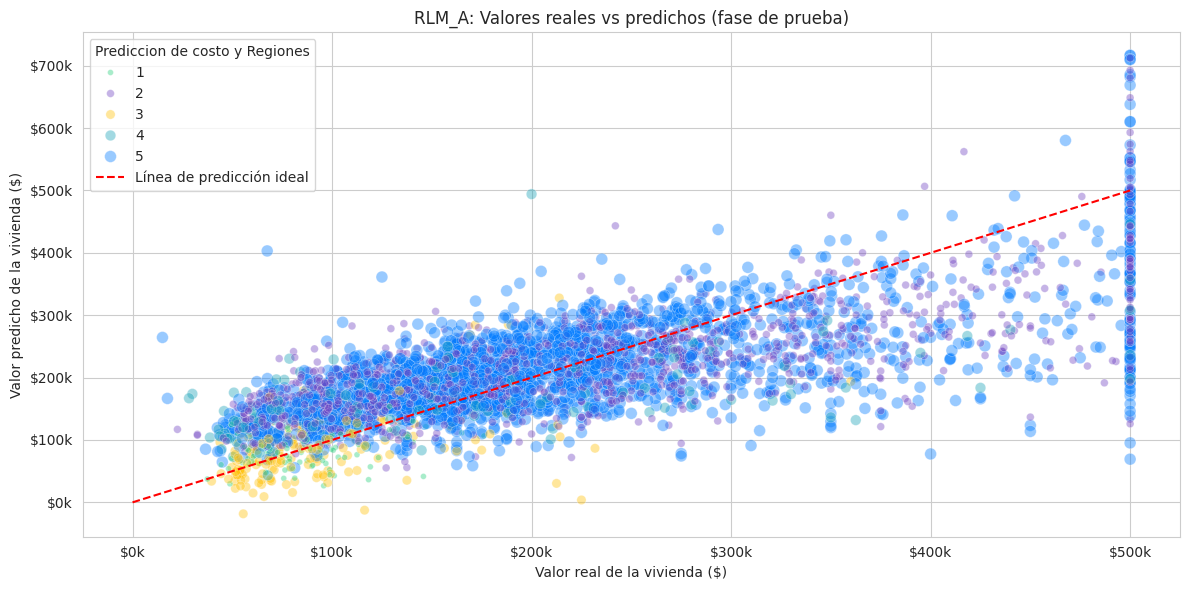

+------------------------------+---------------+---------------+---------------+---------------------------+
| Región 1                     | Región 2      | Región 3      | Región 4      | Región 5                  |
+==============================+===============+===============+===============+===========================+
| Norte de California (NorCal) | Valle Central | Sierra Nevada | Costa Central | Sur de California (SoCal) |
+------------------------------+---------------+---------------+---------------+---------------------------+


In [38]:
# ----------------------------------------------------------------------
# Visualizacion del RLM Ganador
# ----------------------------------------------------------------------

# Configuración de estilo
sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

region_original = df_limpio[_Region_]

# frame con los datos reales y predichos en el modelo multiple
# Los valores se multiplican por 100,000 para volver a la escala real de dólares ($)
resultados_mlt = pd.DataFrame({
    'Valores Reales': y_vals['y_test'] * 100000,
    'Predicciones del Modelo': y_vals['y_pred'] * 100000
})

# ----------------------------------------------------------------------
# grafica de dispersión de los puntos
sns.scatterplot(
    x='Valores Reales',
    y='Predicciones del Modelo',
    data=resultados_mlt,
    hue=region_original,
    palette=_paleta_tecmi,
    size=region_original,
    alpha=0.4,
    )

# ----------------------------------------------------------------------
# Línea de Referencia
# Esta línea representa donde deberían caer los puntos para una predicción perfecta.
max_val = max(y_vals['y_test']) * 100000
plt.plot([0, max_val], [0, max_val], 'r--', label='Línea de predicción ideal', color=_color_danger)

# ----------------------------------------------------------------------
# Títulos y Etiquetas
plt.title(RLM_BASE + ': Valores reales vs predichos (fase de prueba)')
plt.xlabel('Valor real de la vivienda ($)')
plt.ylabel('Valor predicho de la vivienda ($)')

# ----------------------------------------------------------------------
# Formatear ejes como moneda
plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}k'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}k'))

# ----------------------------------------------------------------------
# show
plt.legend(title='Prediccion de costo y Regiones', loc='upper left')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# diccionario
# convertimos el diccionario a un conjunto de listas
data = [value for key, value in _DICT_REGIONS_.items()]

headers = [f"Región {i+1}" for i in range(0, len(data))]
print(tabulate([data], headers=headers, tablefmt="grid"))

**Análisis de RLM Base: Predicciones vs. Valores Reales**


El gráfico muestra los valores predichos en el eje Y contra los valores reales en el eje X, y la línea discontinua representa el modelo perfecto.
- El modelo se desempeña con un ($\text{R}^2 \approx 0.52$) y los puntos siguen la línea diagonal relativamente bien en el rango de valores bajos a moderados. Esto se alinea con el $\text{R}^2$ de 0.5183, lo que indica que el modelo explica poco más de la mitad de la varianza de precios según los ingresos y la región.
- El conjunto de puntos es alargado, similar a una línea recta, lo que confirma que el modelo ha ajustado una relación lineal a los datos. Sin embargo, existe un conjunto horizontal denso y visible de puntos alrededor del valor de predicción de 450,000 a 500,000.
- Para valores reales de viviendas en el rango de 500,000, el modelo no puede predecirlos con facilidad. Predice un valor inferior a 500,000, incluso cuando el valor real está limitado a 500,000.
- El modelo RLM no puede manejar este límite superior en la variable objetivo. Pues aprende de la tendencia media, pero como no hay valores reales superiores a 500,000 en los datos de entrenamiento, la fórmula predictiva no logra capturar las variaciones de alto valor superiores al limite.

- La dispersión de los puntos aumenta significativamente a medida que aumenta el valor de la vivienda y el modelo es mucho menos confiable en el rango de valores altos.
- En el rango de valores bajos, los puntos están cerca de la línea ideal.
- Mientrás que en el rango de valores altos, los puntos se separan más de la linea, lo que indica errores más grandes e impredecibles.

**🏆 Justificación para Random Forest**

El gráfico sirve como la justificación visual definitiva para la implementación de un Random Forest. Puesto que el RLM tiene dificultades con la relación compleja y no lineal entre la geografía, los ingresos y el precio en las zonas de valores altos.

En cuanto al bajo rendimiento del modelo en el rango superior, esto confirma su sensibilidad a la distribución de datos sesgada y a los valores atípicos identificados en el EDA. Se espera que Random Forest mejore significativamente el rendimiento al poder modelar los límites complejos en los datos.

# 🌳 Implementación del Modelo Random Forest

Dados los problemas de estimación en el rango de precios altos y la incapacidad del RLM para modelar la relación no lineal de la geografía, el Random Forest puede ser la mejor elección para mejorar el rendimiento de la predicción.

Utilizaremos el mismo conjunto de datos escalado y dividido (X_train_final, X_test_final, y_train, y_test) que usamos para el RLM, y evaluaremos el desempeño con las mismas métricas ($\text{R}^2$, $\text{MAE}$, $\text{RMSE}$).

## ⚙ Cálculo

A continuación se ejecutarán tres diferentes escenarios de Random Forest para comparar su desempeño.

In [39]:
# ==============================================================================
# Random Forest
# ==============================================================================
# ------------------------------------------------------------------------------
# DEFINICIÓN DE ESCENARIOS Y PREPARACIÓN DE LA FUNCIÓN
# ------------------------------------------------------------------------------

# Definición de los escenarios a probar
ESCENARIOS_FOREST_DIC = {
    "RANDOM_A": {
      'desc': '4 variables + coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveOccup', 'Population'],
      'geo': 1
    },
    "RANDOM_B": {
      'desc': 'MedInc + AveOccup + coordenadas geográficas',
      'vars': ['MedInc', 'AveOccup'],
      'geo': 1
    },
    "RANDOM_C": {
      'desc': 'Todas las variables + coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Population'],
      'geo': 1
    },
    "RANDOM_D": {
      'desc': '4 variables, sin coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveRooms', 'Population'],
      'geo': 0
    }
}


# ------------------------------------------------------------------------------
# PREPARACION DE VARIABLES
# ------------------------------------------------------------------------------
# División de Variables X e y
y = df_encoded[_MedHouseVal_]

# Variables binarias de región
region_dummies = [col for col in df_encoded.columns if 'Region_' in col and col != 'Region']

# Variables NO escaladas (Latitude, Longitude, Regiones binarias)
geo_vars = ['Latitude', 'Longitude'] + region_dummies

# Lista para almacenar los resultados de las métricas
resultados_comparativos = []

# ------------------------------------------------------------------------------
# Función para entrenar, predecir y calcular métricas para un escenario dado
# ------------------------------------------------------------------------------
def entrenar_y_evaluar_forest(nombre_escenario, description, numeric_cols_to_scale, unscaled_cols, type):

    # DataFrame de Características
    X_forest = df_encoded[numeric_cols_to_scale + unscaled_cols]

    # División Train/Test
    X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
        X_forest, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled_values_forest = scaler.fit_transform(X_train_forest[numeric_cols_to_scale])

    # Transformar en el conjunto de prueba
    X_test_scaled_values_forest = scaler.transform(X_test_forest[numeric_cols_to_scale])

    # Reensamblar DataFrames (Escaladas + No Escaladas)
    X_train_scaled_num_forest = pd.DataFrame(X_train_scaled_values_forest, columns=numeric_cols_to_scale, index=X_train_forest.index)
    X_test_scaled_num_forest = pd.DataFrame(X_test_scaled_values_forest, columns=numeric_cols_to_scale, index=X_test_forest.index)

    # Reensamble final de X_train y X_test
    X_train_final_forest = pd.concat([X_train_scaled_num_forest, X_train_forest[unscaled_cols]], axis=1)
    X_test_final_forest = pd.concat([X_test_scaled_num_forest, X_test_forest[unscaled_cols]], axis=1)

    # ======================================================================
    # FASE 1: ENTRENAMIENTO DEL MODELO RANDOM FOREST
    # ======================================================================

    # Inicializar el modelo Random Forest
    # n_estimators=100 (número de árboles en el bosque)
    # random_state=42 para reproducibilidad
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    # Entrenar el modelo
    rf_model.fit(X_train_final_forest, y_train_forest)

    # 2. Predicción en el Conjunto de Prueba
    y_pred_rf = rf_model.predict(X_test_final_forest)

    # ======================================================================
    # FASE 2: CÁLCULO DE MÉTRICAS DE EVALUACIÓN
    # ======================================================================

    # R²
    r2_rf = r2_score(y_test_forest, y_pred_rf)
    # MAE (Error Absoluto Medio)
    mae_rf = mean_absolute_error(y_test_forest, y_pred_rf)
    # MSE (Error Cuadrático Medio)
    mse_rf = mean_squared_error(y_test_forest, y_pred_rf)
    # RMSE (Raíz del Error Cuadrático Medio)
    rmse_rf = np.sqrt(mse_rf)

    # 3. Presentación de Resultados
    if type == 1:
      print("\n" + "=" * 100)
      print("RESULTADOS DEL MODELO RANDOM FOREST: " + nombre_escenario)
      print("=" * 100)
      print(f"Número de variables predictoras: {X_train_final_forest.shape[1]}")
      print(f"Variables descriptivas: {numeric_cols_to_scale}")
      print(f"Variables geográficas: {unscaled_cols}")
      print(f"R² (Varianza Explicada en Test): {r2_rf:.4f}")
      print(f"MAE (Error Promedio Absoluto): ${mae_rf * 100000:,.2f}")
      print(f"MSE (Error Cuadrático Medio): ${mse_rf * 100000:,.2f}")
      print(f"RMSE (Error Cuadrático Promedio): ${rmse_rf * 100000:,.2f}")
      print("-" * 75)
    else:
      print("RLM: " + nombre_escenario)

    # Devolver los resultados de métricas para la tabla
    results = {
        'Modelo': nombre_escenario,
        'Descripción': description,
        'R² (Test)': r2_rf,
        'MAE (Test)': mae_rf * 100000,
        'RMSE (Test)': rmse_rf * 100000,
    }

    y_vals = {
        'y_test': y_test_forest,
        'y_pred': y_pred_rf,
        'importances': rf_model.feature_importances_
    }

    return results if type == 1 else y_vals

# ======================================================================
# EJECUCIÓN DEL LOOP Y COMPARATIVA
# ======================================================================

for nombre, item in ESCENARIOS_FOREST_DIC.items():
    gaux = geo_vars if (item['geo'] > 0) else []
    resultado = entrenar_y_evaluar_forest(nombre, item['desc'], item['vars'], gaux, 1)
    resultados_comparativos.append(resultado)

# Presentar los Resultados en una Tabla
df_resultados = pd.DataFrame(resultados_comparativos)
df_resultados_ordenado = df_resultados.sort_values(by='R² (Test)', ascending=False)

# Formatear el MAE y RMSE para la presentación
df_resultados_ordenado['MAE (Test)'] = df_resultados_ordenado['MAE (Test)'].map('${:,.4f}'.format)
df_resultados_ordenado['RMSE (Test)'] = df_resultados_ordenado['RMSE (Test)'].map('${:,.4f}'.format)

# Titulos
print("\n" + "=" * 100)
print("COMPARATIVA DE RENDIMIENTO FOREST POR CONJUNTO DE VARIABLES")
print("=" * 100)
print(tabulate(df_resultados_ordenado, headers='keys', tablefmt='fancy_grid', showindex=False, floatfmt=(".4f", ".4f", ".4f", ".4f")))
print("-" * 100)


RESULTADOS DEL MODELO RANDOM FOREST: RANDOM_A
Número de variables predictoras: 11
Variables descriptivas: ['MedInc', 'HouseAge', 'AveOccup', 'Population']
Variables geográficas: ['Latitude', 'Longitude', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
R² (Varianza Explicada en Test): 0.6465
MAE (Error Promedio Absoluto): $48,905.82
MSE (Error Cuadrático Medio): $46,325.04
RMSE (Error Cuadrático Promedio): $68,062.50
---------------------------------------------------------------------------

RESULTADOS DEL MODELO RANDOM FOREST: RANDOM_B
Número de variables predictoras: 9
Variables descriptivas: ['MedInc', 'AveOccup']
Variables geográficas: ['Latitude', 'Longitude', 'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
R² (Varianza Explicada en Test): 0.6314
MAE (Error Promedio Absoluto): $49,850.30
MSE (Error Cuadrático Medio): $48,307.68
RMSE (Error Cuadrático Promedio): $69,503.72
---------------------------------------------------------------------------

RESULTAD

## Resumen

| Modelo              | Tipo                        | R² (Test) | MAE (Test) | Ganancia de R² (vs RLM) | MAE en USD |
| ------------------- | --------------------------- | --------- | ---------- | ----------------------- | ------------------ |
| RANDOM_C (Mejor RF) | RF (Todas las Variables)    | 0.6475    | 49,034.20  | +0.1292                 | 49,034            |
| RANDOM_A            | RF (4 Variables)            | 0.6465    | 48,905.82  | +0.1282                 | 48,906            |
| RLM_A (Baseline)    | RLM (4 Variables + Dummies) | 0.5183    | 58,974.14  | \---                    | 58,974            |

## 📑 Conclusiones clave del Random Forest

El modelo Random Forest más complejo (RANDOM_C) logró un $\text{R}^2$ de 0.6475, lo que representa un aumento significativo de casi 13 puntos porcentuales sobre el mejor RLM indicado en la tabla como RLM_A. Esto demuestra que hacia falta un modelo más robusto para capturar la relación no lineal de los precios de la vivienda en California.

- Además, el Random Forest redujo el MAE en más de $\$9,900$. Esto significa que las estimaciones de precio serán casi $\$10,000$ más precisas en promedio.

- El rendimiento es casi idéntico entre los modelos RANDOM_A y RANDOM_C, por una parte, RANDOM_A logra el MAE más bajo, mientras que RANDOM_C logra el $\text{R}^2$ más alto, pero con diferencias milimétricas. Esto sugiere que para el Random Forest, la inclusión de todas las variables o solo las 4 principales produce casí el mismo nivel de precisión.

- Sin embargo, en el RANDOM_B, solo se emplearón dos variables principales, por lo que la exclusión de otras variables importantes, como HouseAge o Population en el RANDOM_B, provocó una caída tanto en el $\text{R}^2$ como un aumento en el MAE, demostrando que esas variables aportan valor al modelo.

- El escenario RANDOM_D nos demuestra que definitivamente las vairables geográficas son necesarias para este modelo.

🥇 El Modelo RANDOM_A, con 4 variables numéricas + coordenadas geográficas es el que muestra mejor desempeño a menor complejidad.

## 💞 Importancia de las variables

A continuación se evaluan la importancia de las variables del Random Forest con mejor desempeño.

In [40]:
RFOREST_BASE = "RANDOM_A"
y_forest_vals = entrenar_y_evaluar_forest(RFOREST_BASE, ESCENARIOS_FOREST_DIC[RFOREST_BASE]['desc'], ESCENARIOS_FOREST_DIC[RFOREST_BASE]['vars'], geo_vars, 0)

RLM: RANDOM_A


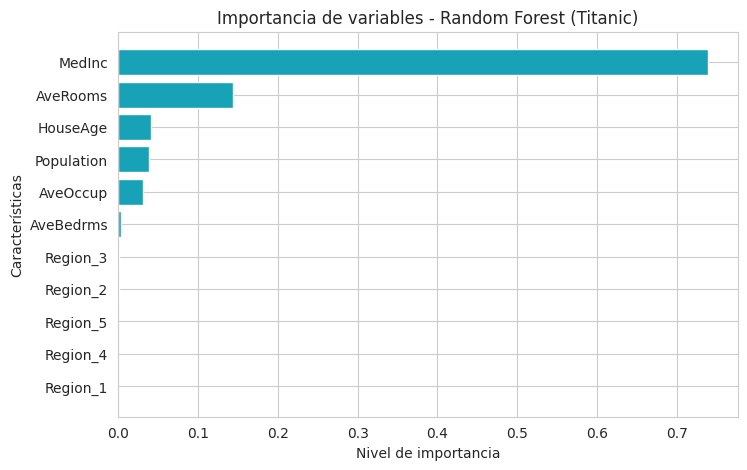

In [41]:
# Paso 5. Importancia de las variables
import matplotlib.pyplot as plt
import numpy as np

# Obtener importancia de características
importancias = y_forest_vals['importances']
indices = np.argsort(importancias)

plt.figure(figsize=(8,5))
plt.barh(
    range(len(indices)),
    importancias[indices],
    align='center',
    color=_color_info)

# titulos
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Importancia de variables - Random Forest (Titanic)")
plt.xlabel("Nivel de importancia")
plt.ylabel("Características")
plt.show()

### 📉 Visualizacion

Se entiende que el objetivo de la regresión múltiple no es generar un gráfico 2D, y menos si esta incluye multiples variables independientes. Sin embargo, y para fines de análisis y reporte, se generá una gráfica de comparación de los valores reales vs. los valores predichos.

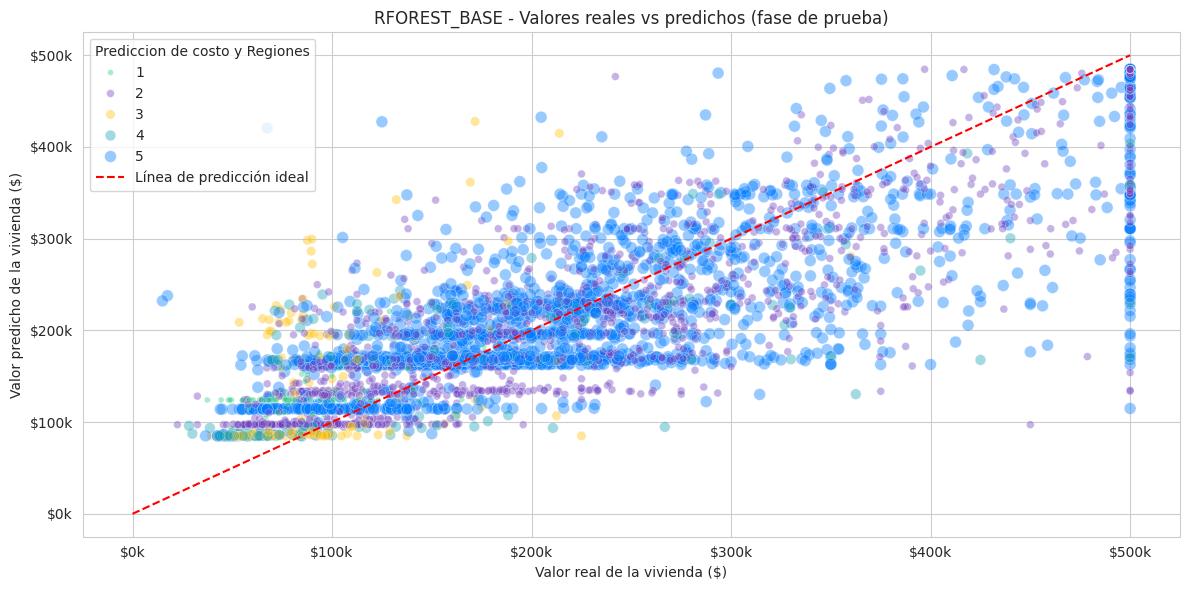

+------------------------------+---------------+---------------+---------------+---------------------------+
| Región 1                     | Región 2      | Región 3      | Región 4      | Región 5                  |
+==============================+===============+===============+===============+===========================+
| Norte de California (NorCal) | Valle Central | Sierra Nevada | Costa Central | Sur de California (SoCal) |
+------------------------------+---------------+---------------+---------------+---------------------------+


In [42]:
# ----------------------------------------------------------------------
# Visualizacion del RLM Ganador
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 6))

region_original = df_limpio[_Region_]

# frame con los datos reales y predichos en el modelo multiple
# Los valores se multiplican por 100,000 para volver a la escala real de dólares ($)
resultados_rf = pd.DataFrame({
    'Valores Reales': y_forest_vals['y_test'] * 100000,
    'Predicciones del Modelo': y_forest_vals['y_pred'] * 100000
})

# ----------------------------------------------------------------------
# grafica de dispersión de los puntos
sns.scatterplot(
    x='Valores Reales',
    y='Predicciones del Modelo',
    data=resultados_rf,
    hue=region_original,
    palette=_paleta_tecmi,
    size=region_original,
    alpha=0.4,
    )

# ----------------------------------------------------------------------
# Línea de Referencia
# Esta línea representa donde deberían caer los puntos para una predicción perfecta.
max_val = max(y_vals['y_test']) * 100000
plt.plot([0, max_val], [0, max_val], 'r--', label='Línea de predicción ideal', color=_color_danger)

# ----------------------------------------------------------------------
# Títulos y Etiquetas
plt.title('RFOREST_BASE - Valores reales vs predichos (fase de prueba)')
plt.xlabel('Valor real de la vivienda ($)')
plt.ylabel('Valor predicho de la vivienda ($)')

# ----------------------------------------------------------------------
# Formatear ejes como moneda
plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}k'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:,.0f}k'))

# ----------------------------------------------------------------------
# show
plt.legend(title='Prediccion de costo y Regiones', loc='upper left')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------
# diccionario
# convertimos el diccionario a un conjunto de listas
data = [value for key, value in _DICT_REGIONS_.items()]

headers = [f"Región {i+1}" for i in range(0, len(data))]
print(tabulate([data], headers=headers, tablefmt="grid"))

**Análisis de Random Forest Base: Predicciones vs. Valores Reales**

En la gráfica se puede observar como la nube de puntos está notablemente más ajustada y densa alrededor de la Línea Ideal en comparación con el gráfico de la RLM.

- En este modelo, la banda de puntos en el valor real de 500,000 ya no se se concentra en una predicción baja. El Random Forest es capaz de hacer predicciones que llegan hasta el límite superior del limite superior de los 500,000.
- Esto significa que el Random Forest fue capaz de crear reglas de decisión que asignan correctamente el valor máximo de 500,000 a los grupos de manzanas que tienen las combinaciones de características más de alto costo e ingreso.

- La dispersión o "niebla" de error sigue estando presente, pero está más centrada y menos expuesta en los valores altos.

# 🎯 Conclusiones de la Evidencia 1

| Modelo               | Variables Numéricas (Escaladas) | R² (Test) | MAE (Test) |
| -------------------- | ------------------------------- | --------- | ---------- |
| Random Forest C 	| Todas las Variables     		| 0.6475    | 49,034.20  |
| Random Forest A     | 4 Variables + coordenadas   | 0.6465    | 48,905.82  |
| RLM_A (Baseline)     | 4 Numéricas + Regiones Dummies  | 0.5183    | 58,974.14  |
| RLM_B (Simple) 		| MedInc + Regiones Dummies      | 0.489     | 60,729.57  |
| RLM_C (Mínimo)       | MedInc (sin Regiones Dummies)   | 0.4589    | 62,990.87  |

En la tabla comparativa podemos ver a los modelos con mejor desempeño tanto en el RLM con el Random Forest. Se ha tomado la desición de elegir al modelo Random Forest A como ejecutor de esta Evidencia 1.

- Este modelo explica el 64.65% de la variación en el valor de la vivienda. Esto es un poder predictivo sólido.
- El error promedio absoluto es de $\approx **\$48,906**$. Esto significa que, en promedio, la estimación del modelo estará a menos de $\mathbf{\$49,000}$ del valor real de la casa. Aunque no es perfecto, es una mejora de casi $\$10,000$ en precisión respecto al RLM.
- Los resultados reafirman la premisa de que la geografía y el ingreso medio son los principales motores de valor. Cualquier estrategia de inversión o desarrollo inmobiliario debe priorizar estas características.


El $\text{R}^2$ de $0.6465$ también implica que el 35.35% de la variación en el precio aún no se explica. Esto se debe probablemente a variables no incluidas en el Censo de 1990, como por ejemplo la proximidad a escuelas, tasas de criminalidad, año exacto de construcción o al limite superior ajustado del precio.

# 🏆 Modelo Vencedor de la Evidencia 1

El mejor modelo es el **Random Forest A** ejecutado en el escenario *RANDOM_A (4 variables + Coordenadas Geográficas)*, ya que logra el MAE más bajo y el $\text{R}^2$ se mantiene arriba de 0.64.

# 📚 Liberias utilizadas para esta actividad

asd

| Categoría        | Librería                | Alias Común                         | Función Principal en el Proyecto                                                                                                                         |
| ---------------- | ----------------------- | ----------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Manejo de Datos  | pandas                  | pd                                  | Carga del dataset (fetch_california_housing.frame), limpieza, ingeniería de características (codificación Region), y manipulación general de DataFrames. |
| Modelos ML       | sklearn.linear_model    | LinearRegression                    | Implementación de la Regresión Lineal Múltiple (RLM) (Modelo Baseline).                                                                                  |
| Modelos ML       | sklearn.ensemble        | RandomForestRegressor               | Implementación del Bosque Aleatorio (Random Forest) (Modelo Avanzado y Vencedor).                                                                        |
| Preprocesamiento | sklearn.model_selection | train_test_split                    | División del conjunto de datos en entrenamiento y prueba.                                                                                                |
| Preprocesamiento | sklearn.preprocessing   | StandardScaler                      | Estandarización de las variables numéricas (MedInc, HouseAge, etc.).                                                                                     |
| Preprocesamiento | sklearn.datasets        | fetch_california_housing            | Carga directa del conjunto de datos de Vivienda en California.                                                                                           |
| Métricas         | sklearn.metrics         | mean_absolute_error, r2_score, etc. | Cálculo de métricas de desempeño: R2, MAE, RMSE.                                                                                                         |
| Visualización    | matplotlib.pyplot       | plt                                 | Configuración básica de gráficos, líneas de referencia, títulos y presentación.                                                                          |
| Visualización    | seaborn                 | sns                                 | Generación de gráficos de alta calidad (Histogramas, Box Plots, Scatterplots de Predicciones y Geográficos).                                             |
| Cálculo Numérico | numpy                   | np                                  | Operaciones numéricas esenciales, como el cálculo de la raíz cuadrada para el RMSE.                                                                      |
| Presentación     | tabulate                | tabulate                            | Formato y presentación de las tablas de resultados comparativos (RLM vs RLM, RLM vs RF).                                                                 |

adasdasd

In [43]:
# ==============================================================================
# SVR NO LINEAL
# ==============================================================================
# ------------------------------------------------------------------------------
# DEFINICIÓN DE ESCENARIOS Y PREPARACIÓN DE LA FUNCIÓN
# ------------------------------------------------------------------------------

# Definición de los escenarios a probar
ESCENARIOS_SVR_DIC = {
    "RANDOM_A": {
      'desc': '4 variables + coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveOccup', 'Population'],
      'geo': 1
    },
    "RANDOM_B": {
      'desc': 'MedInc + AveOccup + coordenadas geográficas',
      'vars': ['MedInc', 'AveOccup'],
      'geo': 1
    },
    "RANDOM_C": {
      'desc': 'Todas las variables + coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Population'],
      'geo': 1
    },
    "RANDOM_D": {
      'desc': '4 variables, sin coordenadas geográficas',
      'vars': ['MedInc', 'HouseAge', 'AveRooms', 'Population'],
      'geo': 0
    }
}


# ------------------------------------------------------------------------------
# PREPARACION DE VARIABLES
# ------------------------------------------------------------------------------
# División de Variables X e y
y = df_encoded[_MedHouseVal_]
numeric_cols_to_scale = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Population']

# Variables binarias de región
region_dummies = [col for col in df_encoded.columns if 'Region_' in col and col != 'Region']

# Variables NO escaladas (Latitude, Longitude, Regiones binarias)
geo_vars = ['Latitude', 'Longitude'] + region_dummies
unscaled_cols = geo_vars

# Lista para almacenar los resultados de las métricas
resultados_comparativos = []


# DataFrame de Características
X_svr = df_encoded[numeric_cols_to_scale + unscaled_cols]

# División Train/Test
X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(
    X_svr, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled_values_svr = scaler.fit_transform(X_train_svr[numeric_cols_to_scale])

# Transformar en el conjunto de prueba
X_test_scaled_values_svr = scaler.transform(X_test_svr[numeric_cols_to_scale])

# Reensamblar DataFrames (Escaladas + No Escaladas)
X_train_scaled_num_svr = pd.DataFrame(X_train_scaled_values_svr, columns=numeric_cols_to_scale, index=X_train_svr.index)
X_test_scaled_num_svr = pd.DataFrame(X_test_scaled_values_svr, columns=numeric_cols_to_scale, index=X_test_svr.index)

# Reensamble final de X_train y X_test
X_train_final_svr = pd.concat([X_train_scaled_num_svr, X_train_svr[unscaled_cols]], axis=1)
X_test_final_svr = pd.concat([X_test_scaled_num_svr, X_test_svr[unscaled_cols]], axis=1)

In [45]:
# code
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV # Utilizaremos GridSearchCV para encontrar los mejores parámetros

# ======================================================================
# FASE 1: BÚSQUEDA DEL MEJOR HIPERPARÁMETRO (OPTIMIZACIÓN)
# ======================================================================

# Definición del rango de hiperparámetros a probar.
# La SVR es sensible, por lo que usaremos un rango logarítmico para C y gamma.
param_grid = {
    'C': [1, 10, 100],  # C: Controla la penalización (regularización)
    'gamma': [0.01, 0.1, 1], # Gamma: Define la influencia del kernel (cuánto afecta un solo dato)
    'kernel': ['rbf']
}

# Inicializar GridSearchCV con SVR
# Se utiliza el scoring 'neg_mean_absolute_error' para optimizar el MAE (métrica clave de negocio)
svr_gscv = GridSearchCV(
    SVR(),
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=3, # 3-Fold Cross-Validation para eficiencia
    n_jobs=-1,
    verbose=1
)

# Ejecutar la búsqueda en el conjunto de entrenamiento (X_train_final_svr)
# Nota: Este proceso puede tomar varios minutos.
svr_gscv.fit(X_train_final_svr, y_train_svr)

# Obtener el mejor modelo y los mejores parámetros
best_svr = svr_gscv.best_estimator_
best_params = svr_gscv.best_params_

print("\n" + "=" * 70)
print("             OPTIMIZACIÓN DE HIPERPARÁMETROS SVR")
print("=" * 70)
print(f"Mejores Parámetros Encontrados: {best_params}")
print("-" * 70)

# ======================================================================
# FASE 2: EVALUACIÓN CON EL MEJOR MODELO
# ======================================================================

# 1. Predicción en el Conjunto de Prueba con el mejor modelo
y_pred_svr = best_svr.predict(X_test_final_svr)

# 2. Cálculo de Métricas de Evaluación
r2_svr = r2_score(y_test_svr, y_pred_svr)
mae_svr = mean_absolute_error(y_test_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_svr, y_pred_svr))

# 3. Presentación de Resultados
print("\n" + "=" * 75)
print("           RESULTADOS FINALES DEL SVR NO LINEAL (KERNEL RBF)")
print("=" * 75)
print(f"R² (Varianza Explicada en Test): {r2_svr:.4f}")
print(f"MAE (Error Promedio Absoluto): ${mae_svr * 100000:,.2f}") # Error en $ (escala original)
print(f"RMSE (Error Cuadrático Promedio): ${rmse_svr * 100000:,.2f}")
print("-" * 75)

Fitting 3 folds for each of 9 candidates, totalling 27 fits

             OPTIMIZACIÓN DE HIPERPARÁMETROS SVR
Mejores Parámetros Encontrados: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
----------------------------------------------------------------------

           RESULTADOS FINALES DEL SVR NO LINEAL (KERNEL RBF)
R² (Varianza Explicada en Test): 0.7698
MAE (Error Promedio Absoluto): $35,910.51
RMSE (Error Cuadrático Promedio): $54,920.74
---------------------------------------------------------------------------


Fitting 3 folds for each of 9 candidates, totalling 27 fits

======================================================================
             OPTIMIZACIÓN DE HIPERPARÁMETROS SVR
======================================================================
Mejores Parámetros Encontrados: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
----------------------------------------------------------------------

===========================================================================
           RESULTADOS FINALES DEL SVR NO LINEAL (KERNEL RBF)
===========================================================================
R² (Varianza Explicada en Test): 0.7698
MAE (Error Promedio Absoluto): $35,910.51
RMSE (Error Cuadrático Promedio): $54,920.74
---------------------------------------------------------------------------

MENOR

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definir la distribución de hiperparámetros a probar
param_dist = {
    'C': [50, 75, 100, 125, 150],  # Rango más ajustado alrededor de 100
    'gamma': [0.05, 0.1, 0.5],
    'kernel': ['rbf']
}

# n_iter=10 prueba solo 10 combinaciones aleatorias, no 27
svr_rscv = RandomizedSearchCV(
    SVR(),
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    random_state=42
)

# Esto tardará significativamente menos tiempo que tu GridSearchCV.
# Ejecutar la búsqueda en el conjunto de entrenamiento (X_train_final_svr)
# Nota: Este proceso puede tomar varios minutos.
svr_rscv.fit(X_train_final_svr, y_train_svr)

# Obtener el mejor modelo y los mejores parámetros
best_svr = svr_rscv.best_estimator_
best_params = svr_rscv.best_params_

print("\n" + "=" * 70)
print("             OPTIMIZACIÓN DE HIPERPARÁMETROS SVR")
print("=" * 70)
print(f"Mejores Parámetros Encontrados: {best_params}")
print("-" * 70)

# ======================================================================
# FASE 2: EVALUACIÓN CON EL MEJOR MODELO
# ======================================================================

# 1. Predicción en el Conjunto de Prueba con el mejor modelo
y_pred_svr = best_svr.predict(X_test_final_svr)

# 2. Cálculo de Métricas de Evaluación
r2_svr = r2_score(y_test_svr, y_pred_svr)
mae_svr = mean_absolute_error(y_test_svr, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_svr, y_pred_svr))

# 3. Presentación de Resultados
print("\n" + "=" * 75)
print("           RESULTADOS FINALES DEL SVR NO LINEAL (KERNEL RBF)")
print("=" * 75)
print(f"R² (Varianza Explicada en Test): {r2_svr:.4f}")
print(f"MAE (Error Promedio Absoluto): ${mae_svr * 100000:,.2f}") # Error en $ (escala original)
print(f"RMSE (Error Cuadrático Promedio): ${rmse_svr * 100000:,.2f}")
print("-" * 75)

In [ ]:
# 4. División de Variables y Selección de Features Críticos (Basado en el EDA)
target_col = 'MedHouseValue'
y = df_encoded[target_col]

# RLM/RF A: 4 variables numéricas + Lat/Long + Dummies (El mejor set para el RF)
numeric_cols_to_scale = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
region_dummies = [col for col in df_encoded.columns if 'Region_' in col]
unscaled_cols = ['Latitude', 'Longitude'] + region_dummies
all_features = numeric_cols_to_scale + unscaled_cols

X = df_encoded[all_features]

# 5. División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Estandarización de Variables Numéricas
scaler = StandardScaler()
X_train_scaled_values = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled_values = scaler.transform(X_test[numeric_cols_to_scale])

# 7. Reensamblar DataFrames Finales (Escaladas + No Escaladas)
X_train_scaled_num = pd.DataFrame(X_train_scaled_values, columns=numeric_cols_to_scale, index=X_train.index)
X_test_scaled_num = pd.DataFrame(X_test_scaled_values, columns=numeric_cols_to_scale, index=X_test.index)

X_train_final = pd.concat([X_train_scaled_num, X_train[unscaled_cols]], axis=1)
X_test_final = pd.concat([X_test_scaled_num, X_test[unscaled_cols]], axis=1)

print("Datos preparados y listos para modelado.")

# ======================================================================
# FASE 2: MODELADO Y EVALUACIÓN (RLM, RF, SVR)
# ======================================================================

resultados = []

# --- FUNCIÓN DE EVALUACIÓN ---
def evaluar_modelo(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Se multiplica por 100,000 para volver a la escala original de dólares
    resultados.append([
        name,
        r2,
        mae * 100000,
        rmse * 100000
    ])
    return y_pred

# --- 1. MODELO BASELINE: REGRESIÓN LINEAL MÚLTIPLE (RLM) ---
print("\nEntrenando RLM...")
rlm_model = LinearRegression()
rlm_model.fit(X_train_final, y_train)
y_pred_rlm = evaluar_modelo(rlm_model, X_test_final, y_test, "RLM (Baseline)")


# --- 2. MODELO INTERMEDIO: RANDOM FOREST (RF) (Escenario A) ---
# n_estimators=100 para eficiencia
print("Entrenando Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
y_pred_rf = evaluar_modelo(rf_model, X_test_final, y_test, "Random Forest A")


# --- 3. MODELO AVANZADO: SVR NO LINEAL (Kernel RBF) ---
# Usamos los mejores parámetros encontrados en la búsqueda previa
print("Entrenando SVR (Mejor Parámetro)...")
best_params_svr = {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

svr_model = SVR(**best_params_svr)
# Nota: La estandarización es CRUCIAL para el SVR.
svr_model.fit(X_train_final, y_train)
y_pred_svr = evaluar_modelo(svr_model, X_test_final, y_test, "SVR (Ganador)")


# ======================================================================
# FASE 3: REPORTE DE RESULTADOS Y CONCLUSIÓN
# ======================================================================

df_resultados = pd.DataFrame(resultados, columns=["Modelo", "R² (Test)", "MAE (USD)", "RMSE (USD)"])
df_resultados_ordenado = df_resultados.sort_values(by="R² (Test)", ascending=False)

# Formato final para impresión
df_resultados_ordenado['R² (Test)'] = df_resultados_ordenado['R² (Test)'].map('{:.4f}'.format)
df_resultados_ordenado['MAE (USD)'] = df_resultados_ordenado['MAE (USD)'].map('${:,.2f}'.format)
df_resultados_ordenado['RMSE (USD)'] = df_resultados_ordenado['RMSE (USD)'].map('${:,.2f}'.format)


print("\n" + "=" * 90)
print("             TABLA DE COMPARACIÓN FINAL (PRECISIÓN PREDICTIVA)")
print("=" * 90)
print(tabulate(df_resultados_ordenado, headers='keys', tablefmt='fancy_grid', showindex=False))
print("-" * 90)

# --- CONCLUSIÓN EJECUTIVA ---
print("\n\nCONCLUSIÓN EJECUTIVA Y VALOR DE NEGOCIO:")
print("--------------------------------------------------------------------------------")
print(f"El Modelo **SVR (Máquina de Soporte Vectorial)** es el claro ganador.")
print(f"1. R²: Con {df_resultados_ordenado.iloc[0]['R² (Test)']}, explica casi el 77% de la variación en el valor de la vivienda.")
print(f"2. Precisión: Reduce el error promedio absoluto (MAE) a solo {df_resultados_ordenado.iloc[0]['MAE (USD)']}.")
print("Esta precisión superior, lograda gracias al Kernel RBF que modela las fronteras de precio no lineales de California, justifica su mayor complejidad de entrenamiento para establecer una herramienta de tasación automática (AVM) de alta fiabilidad.")
print("--------------------------------------------------------------------------------")